In [5]:
# Imports

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# load in the results
result_dir = "/Users/katiepambakian/Documents/BSc Computer Science/Y3/Dissertation/BeeCommunication/results/"

date = "2026-03-05/"
slurm_job = 16195037

result_dir = result_dir + date + str(slurm_job) + "/"
# result_dir = result_dir + date + "v/"


stages = ["stage3"]
envs = [1,2,3]
trials = [1,2,3]
run = 0

# batches = [3,4,5,7,8,9,10,11,12,13,14,15,16,17,18,19]
# batches=[1, 7, 9, 11, 12, 15, 16, 18]
batches = [15,16,18]

In [6]:
def read_ith_line(i, filename):
    with open(filename, "r") as file:
        for line_number, line in enumerate(file, start=1):
            if (line_number == i):
                return [float(x) for x in line.strip().split()]
            
    raise ValueError(f"File {filename} has fewer than {i} lines")

/var/folders/fz/htwq5qzj5_d0ry3b14hmlrsw0000gn/T/ipykernel_70853/460762603.py:141: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()
/var/folders/fz/htwq5qzj5_d0ry3b14hmlrsw0000gn/T/ipykernel_70853/460762603.py:5: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig, ax = plt.subplots(figsize=(16,10))


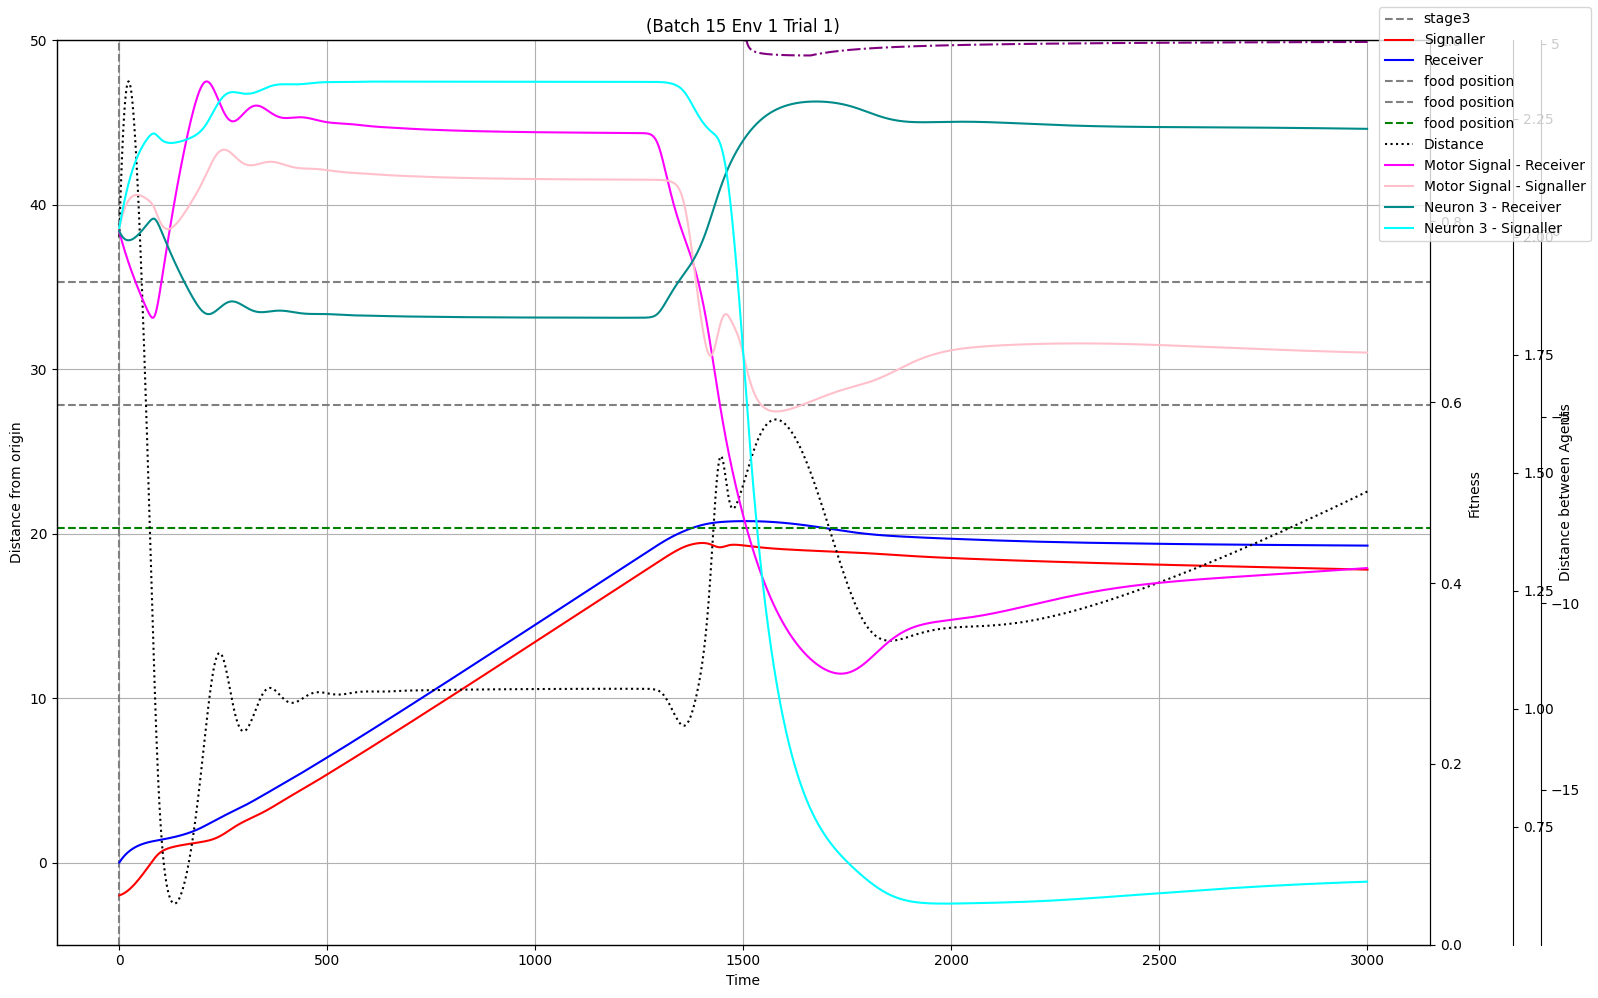

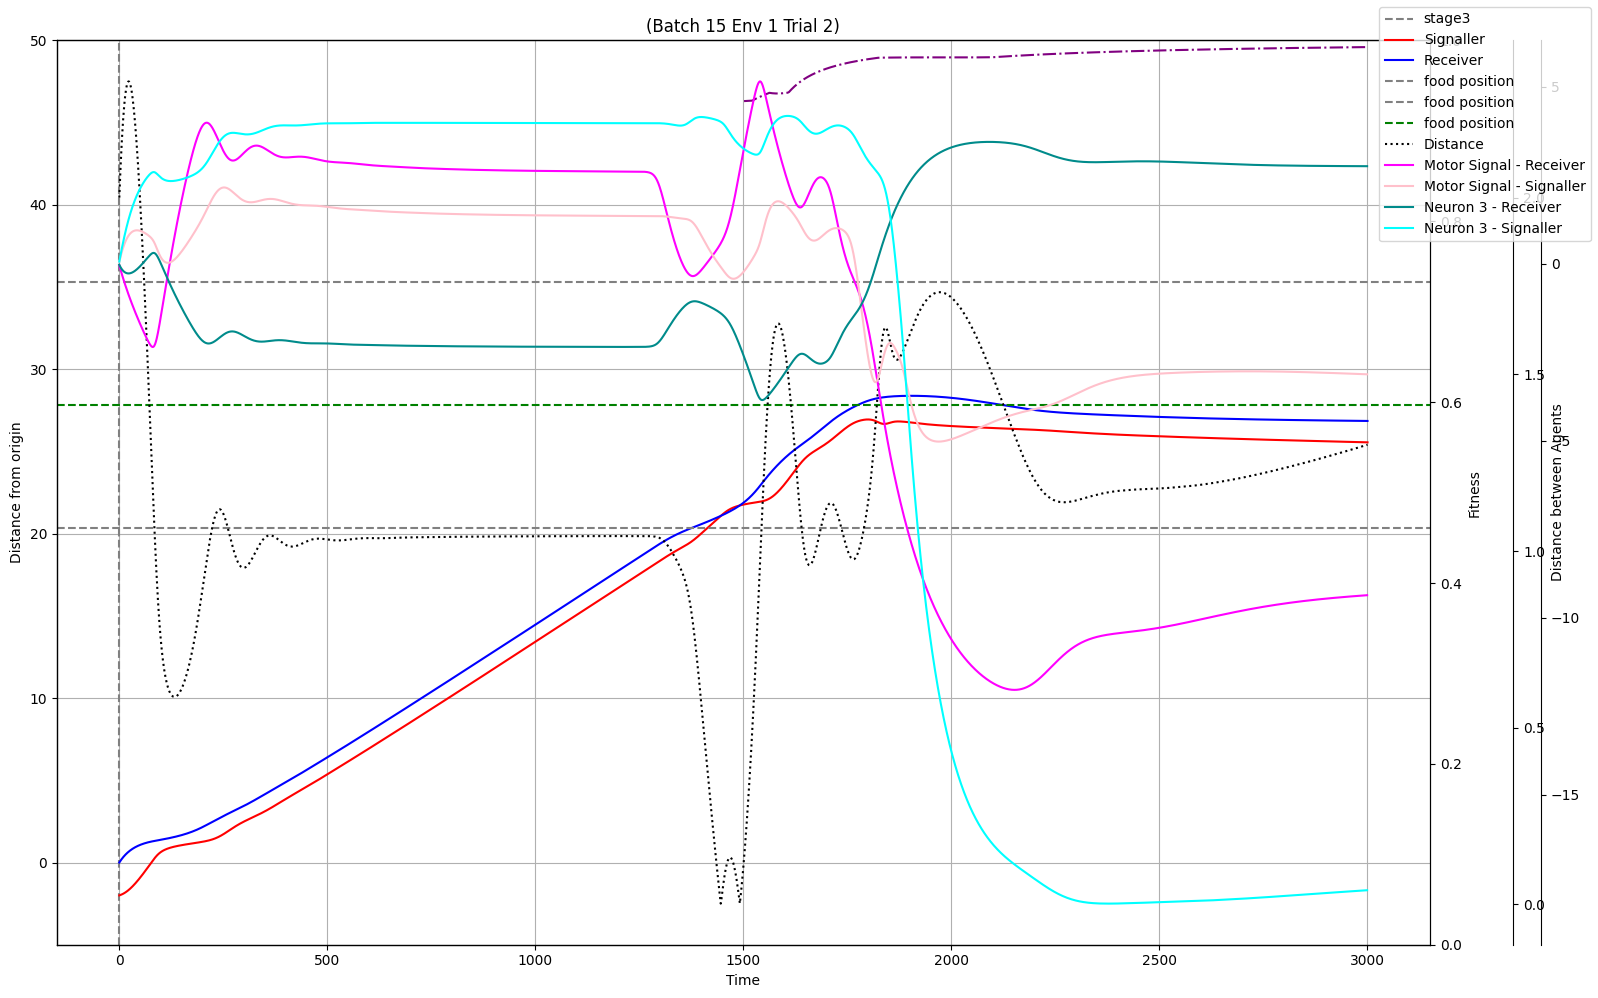

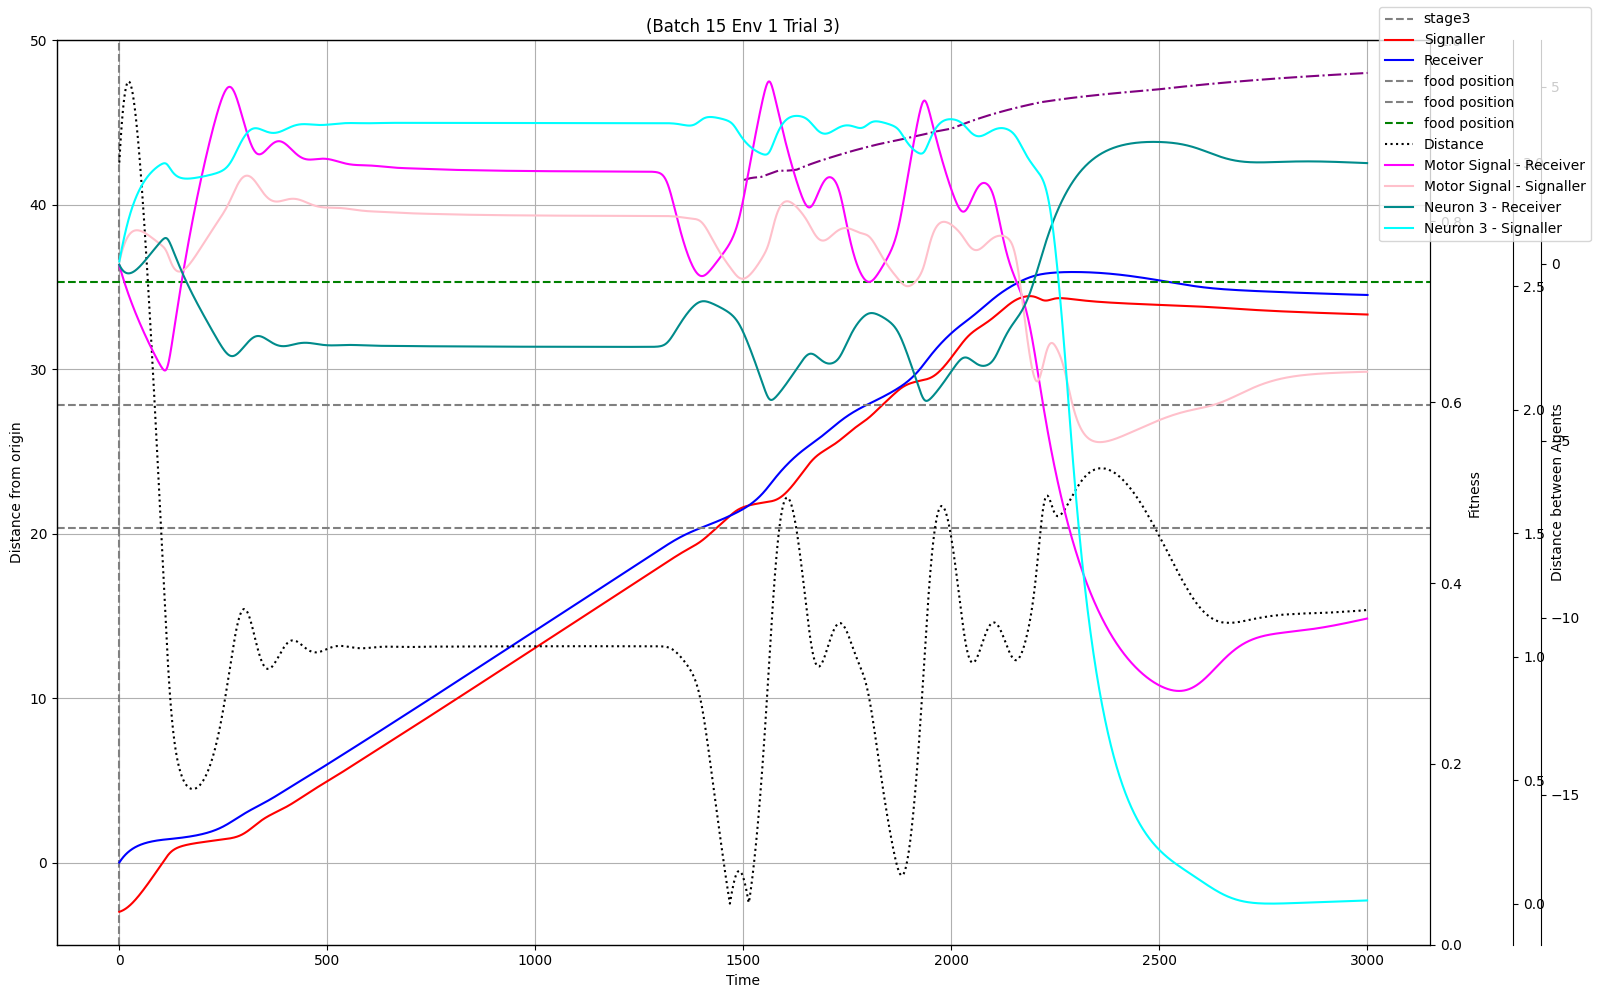

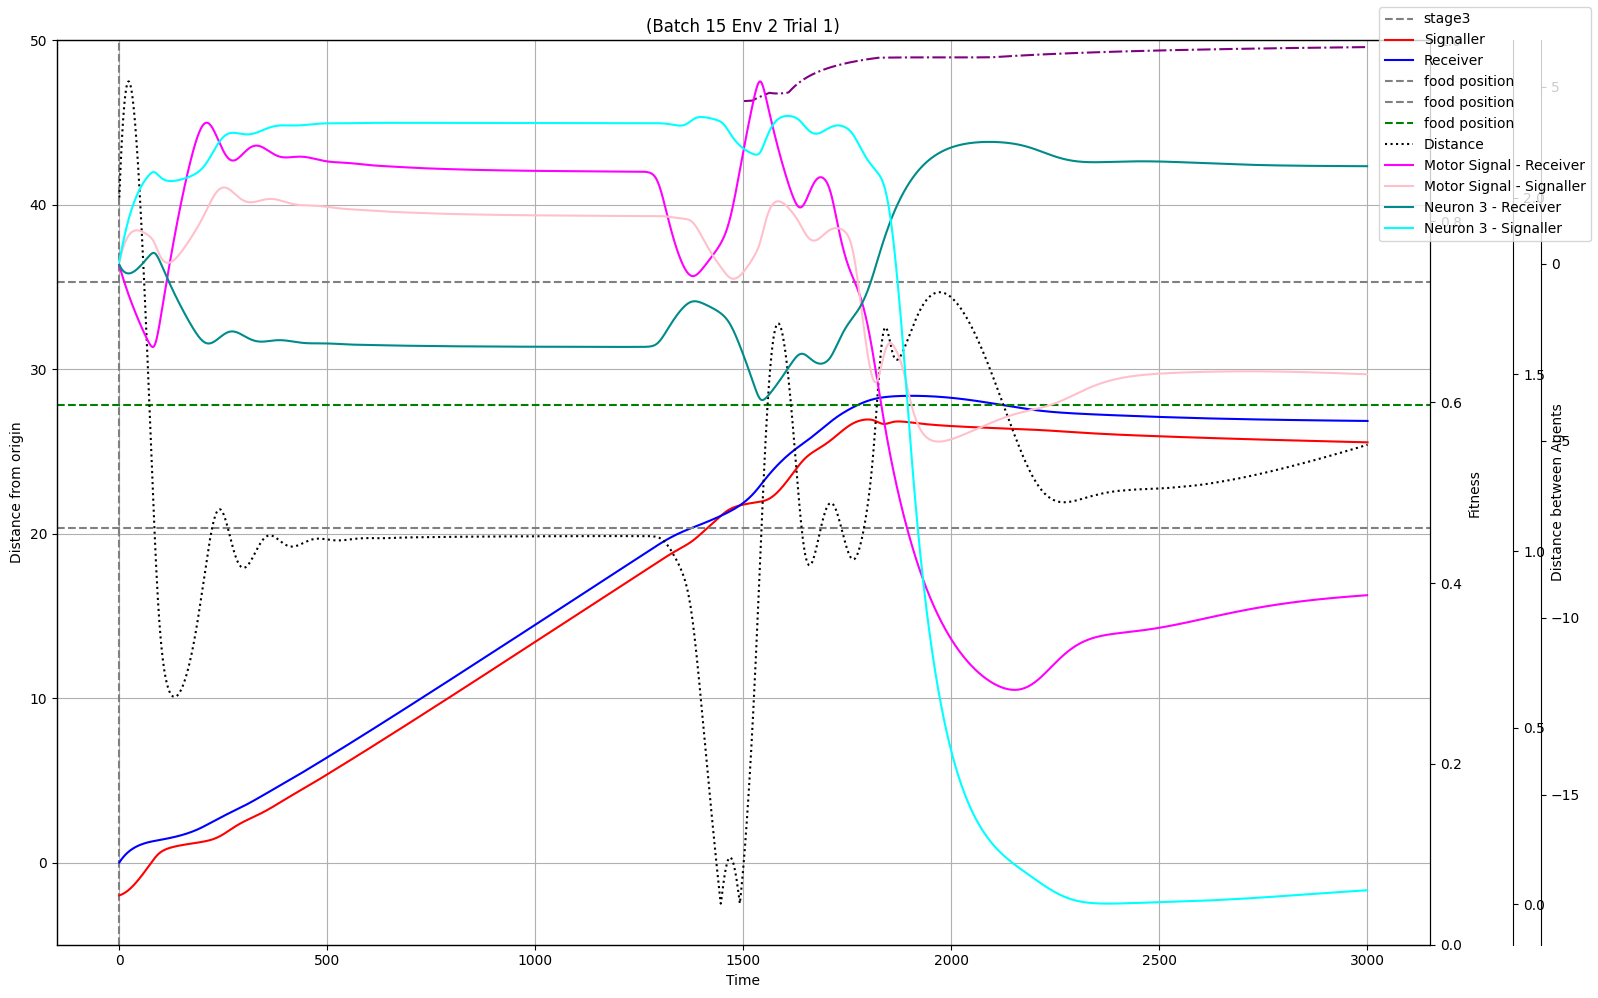

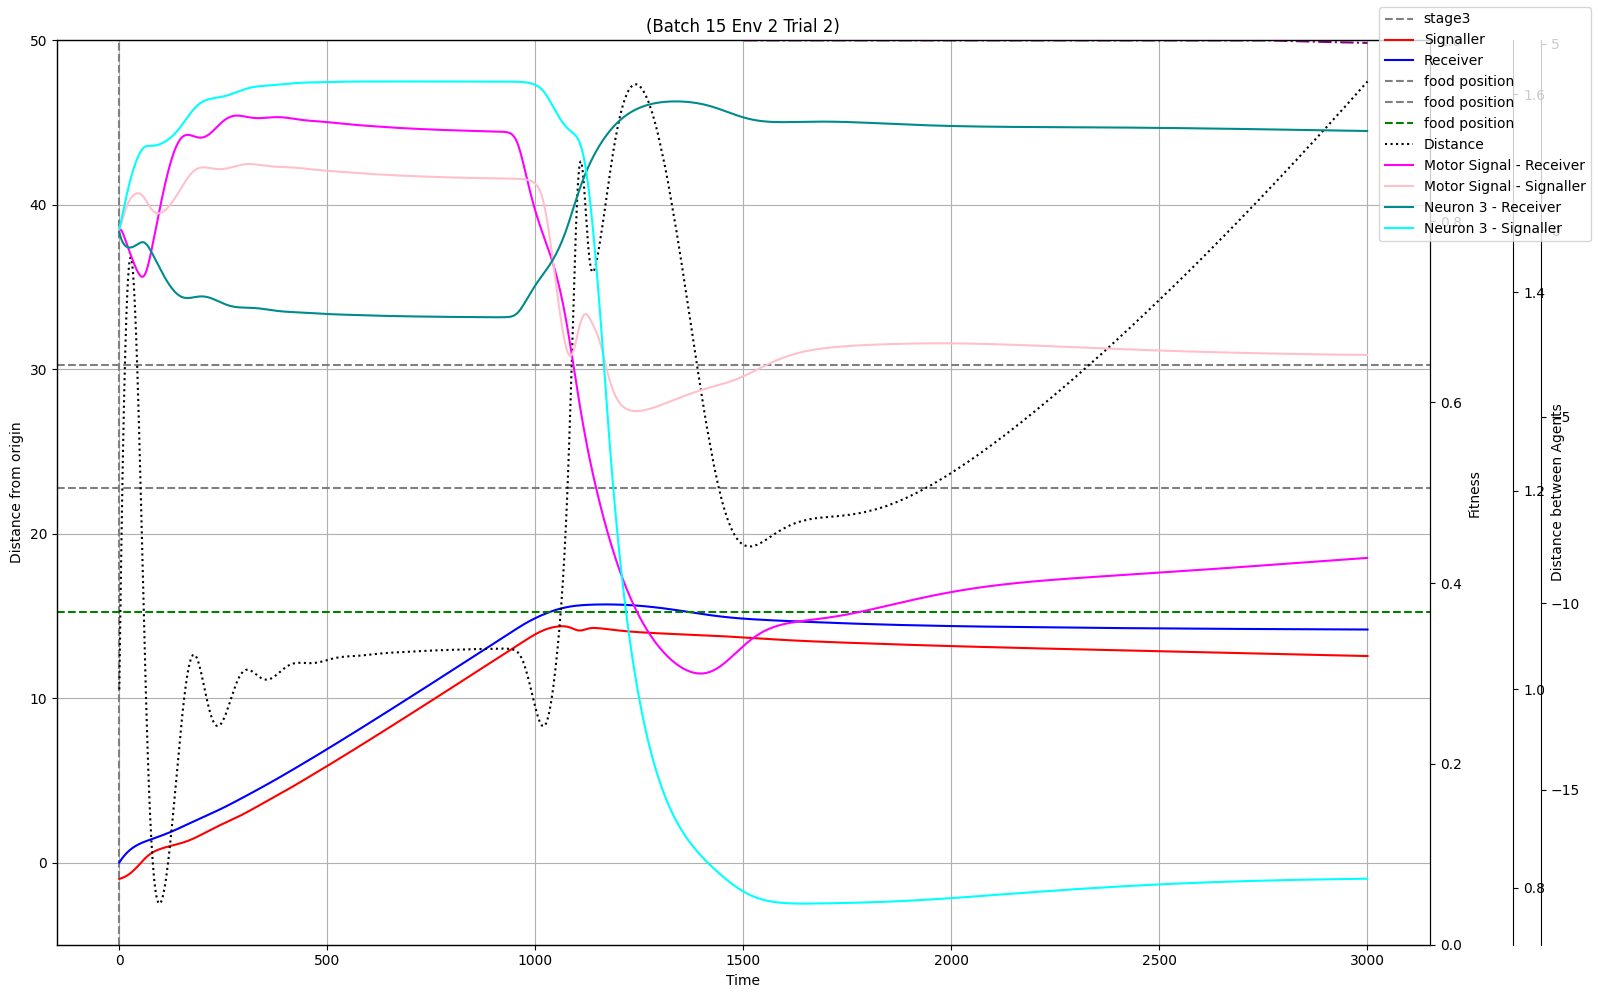

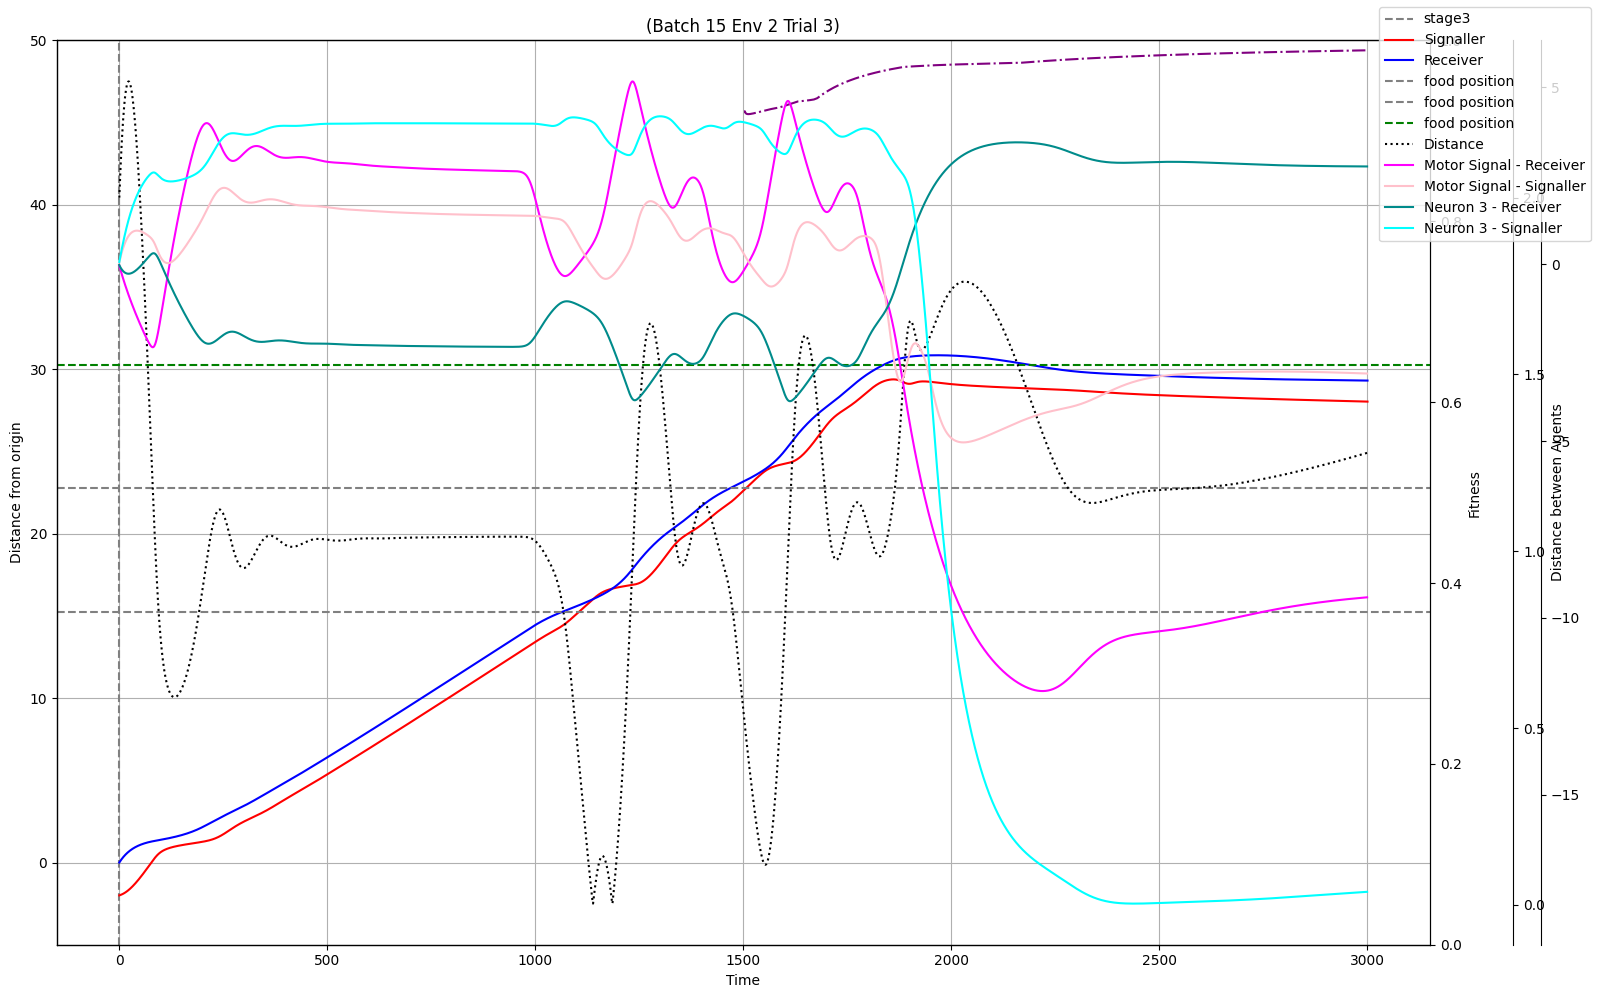

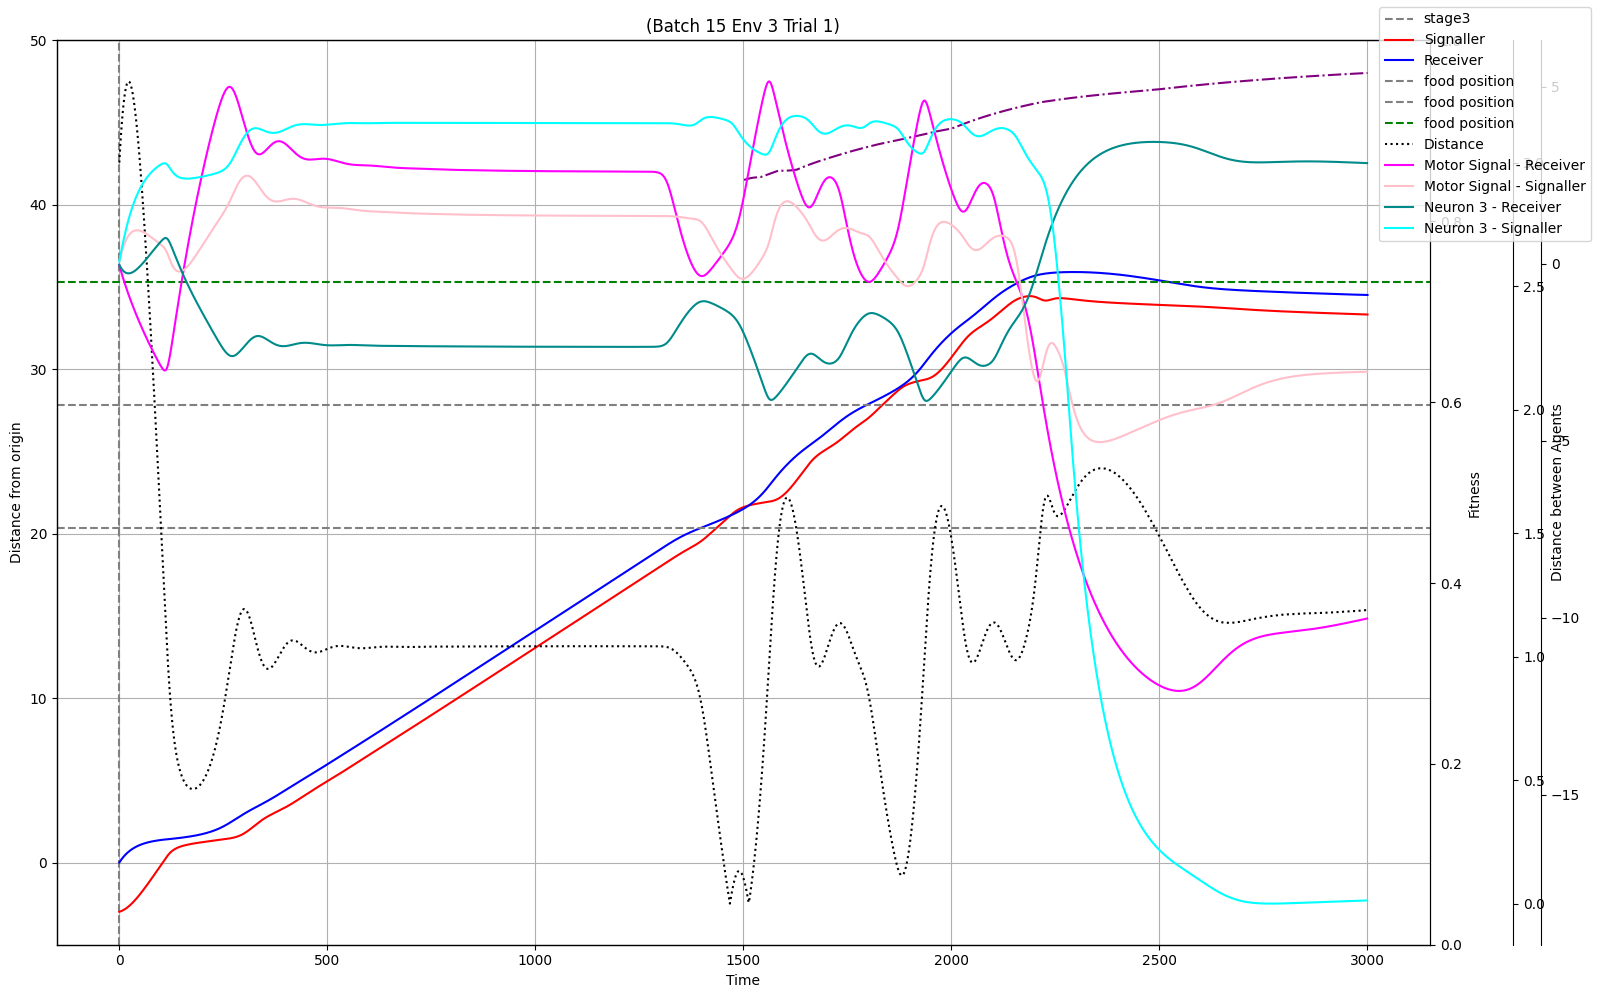

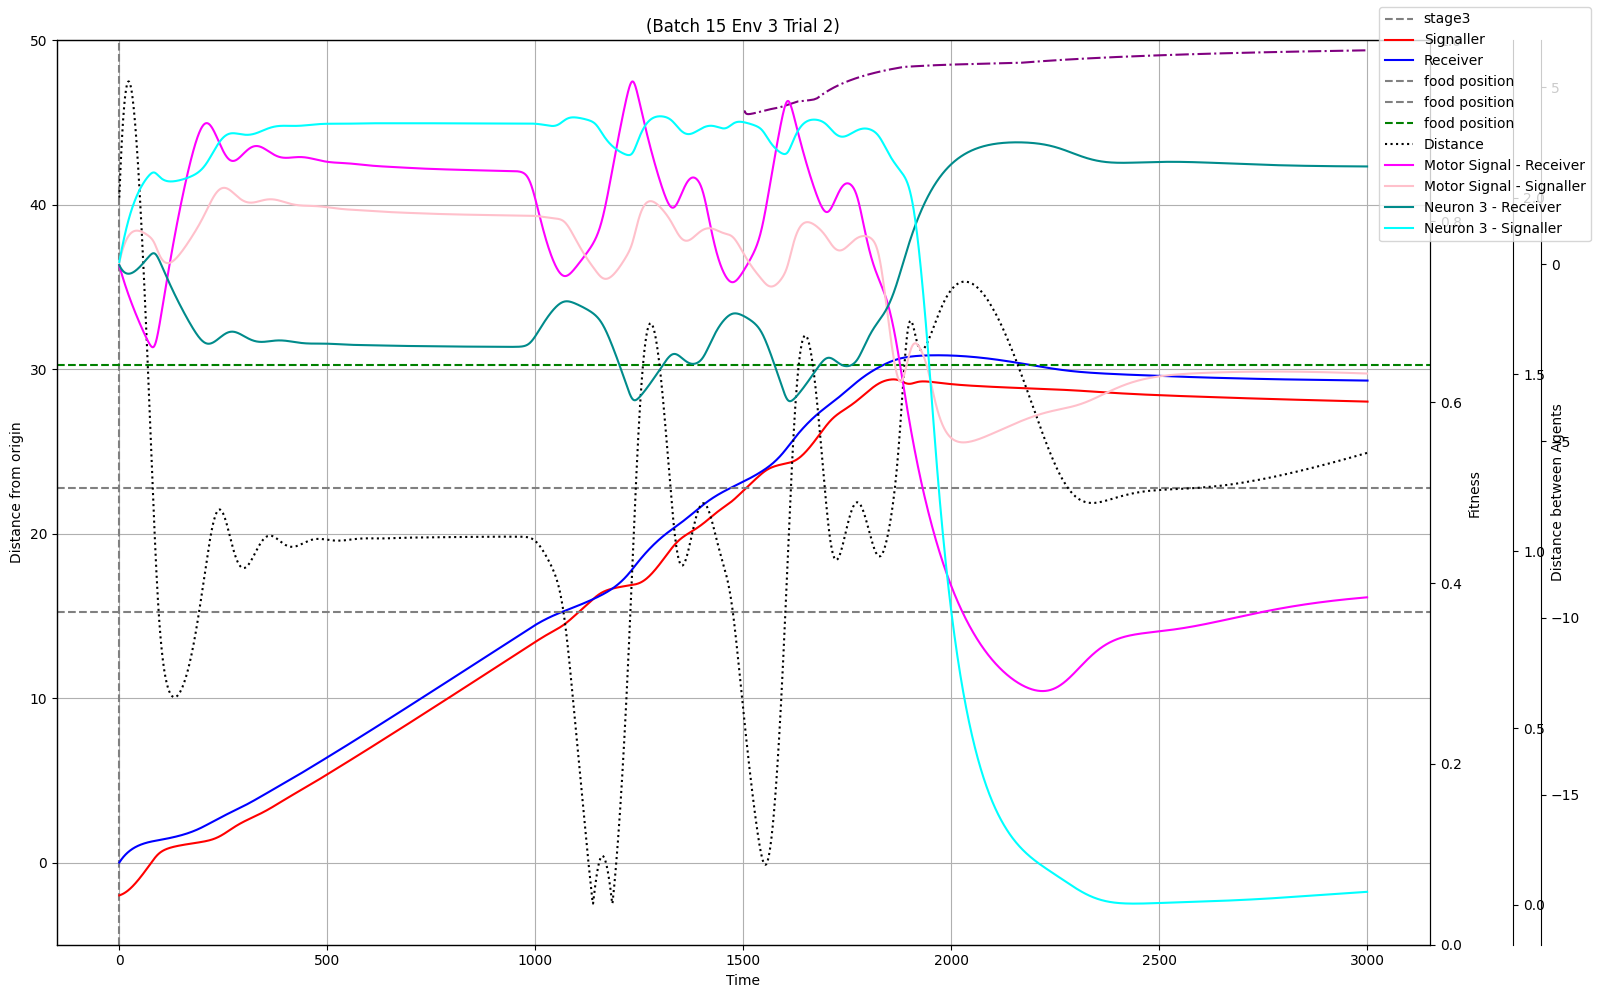

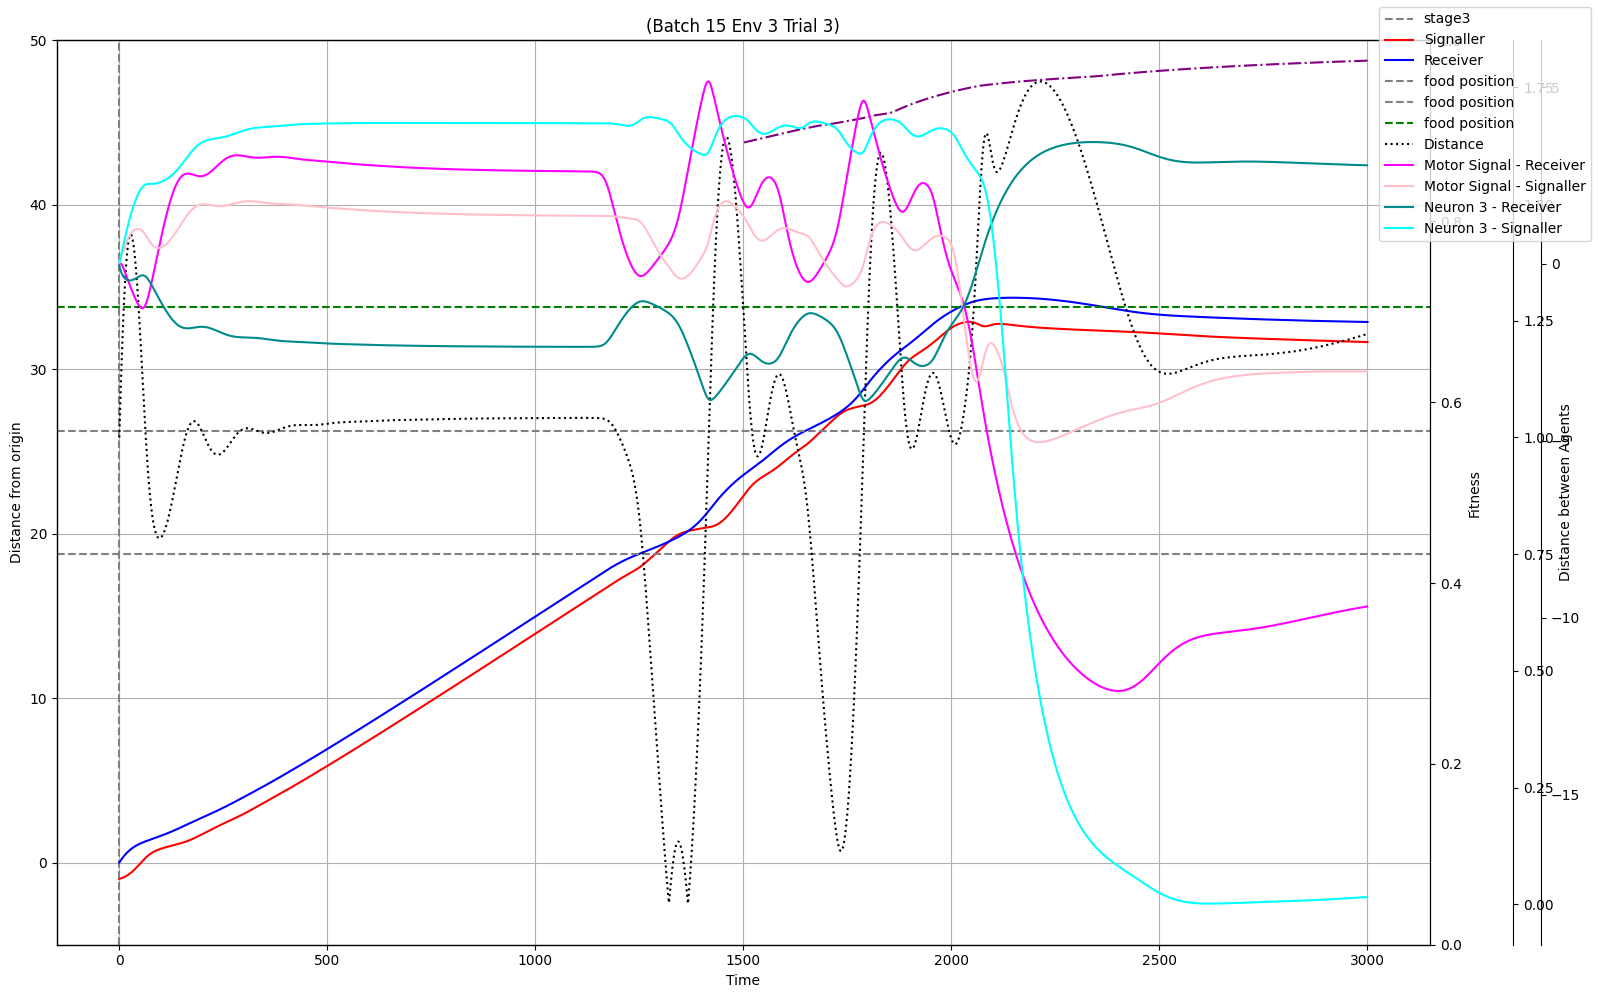

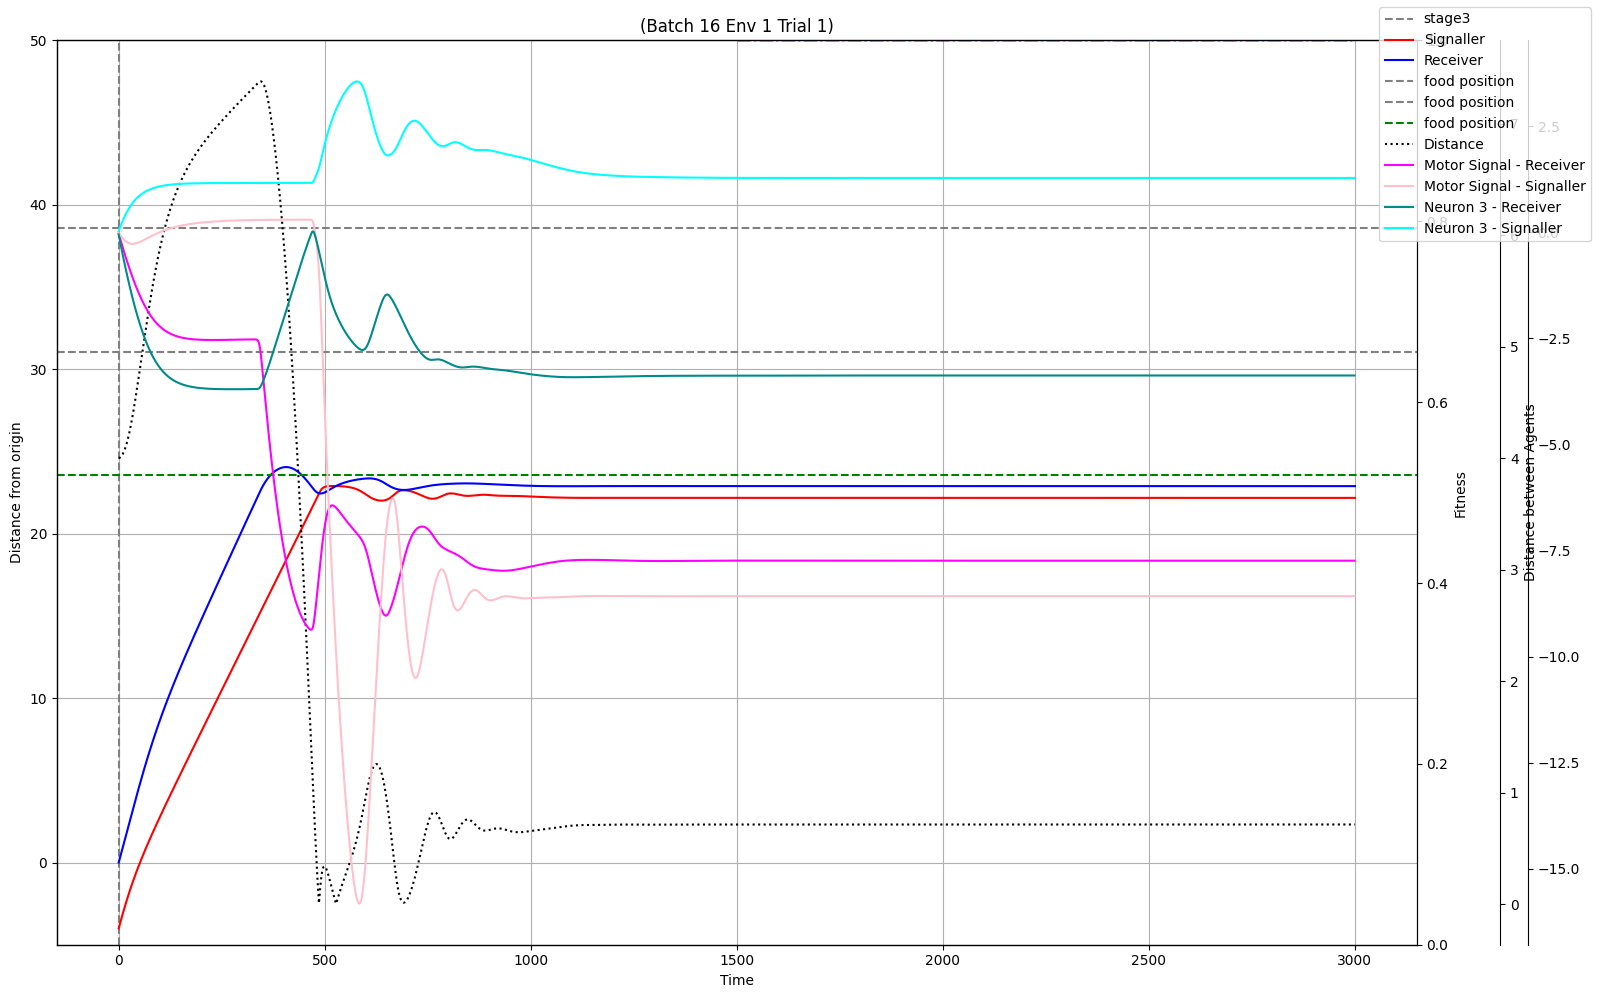

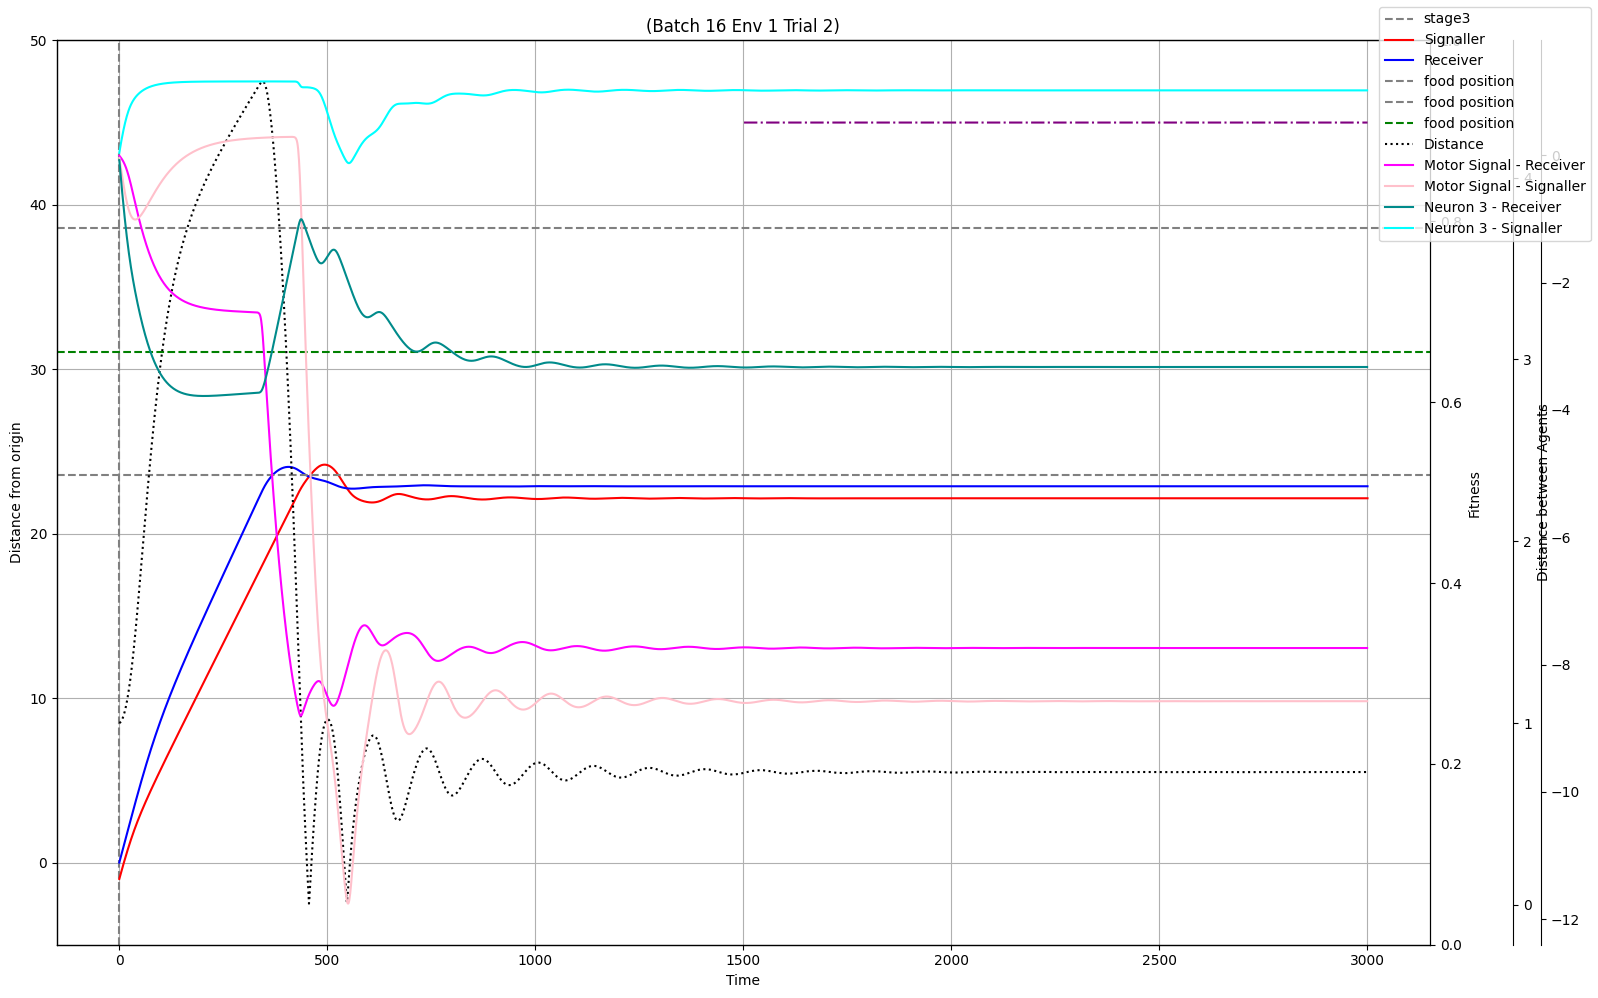

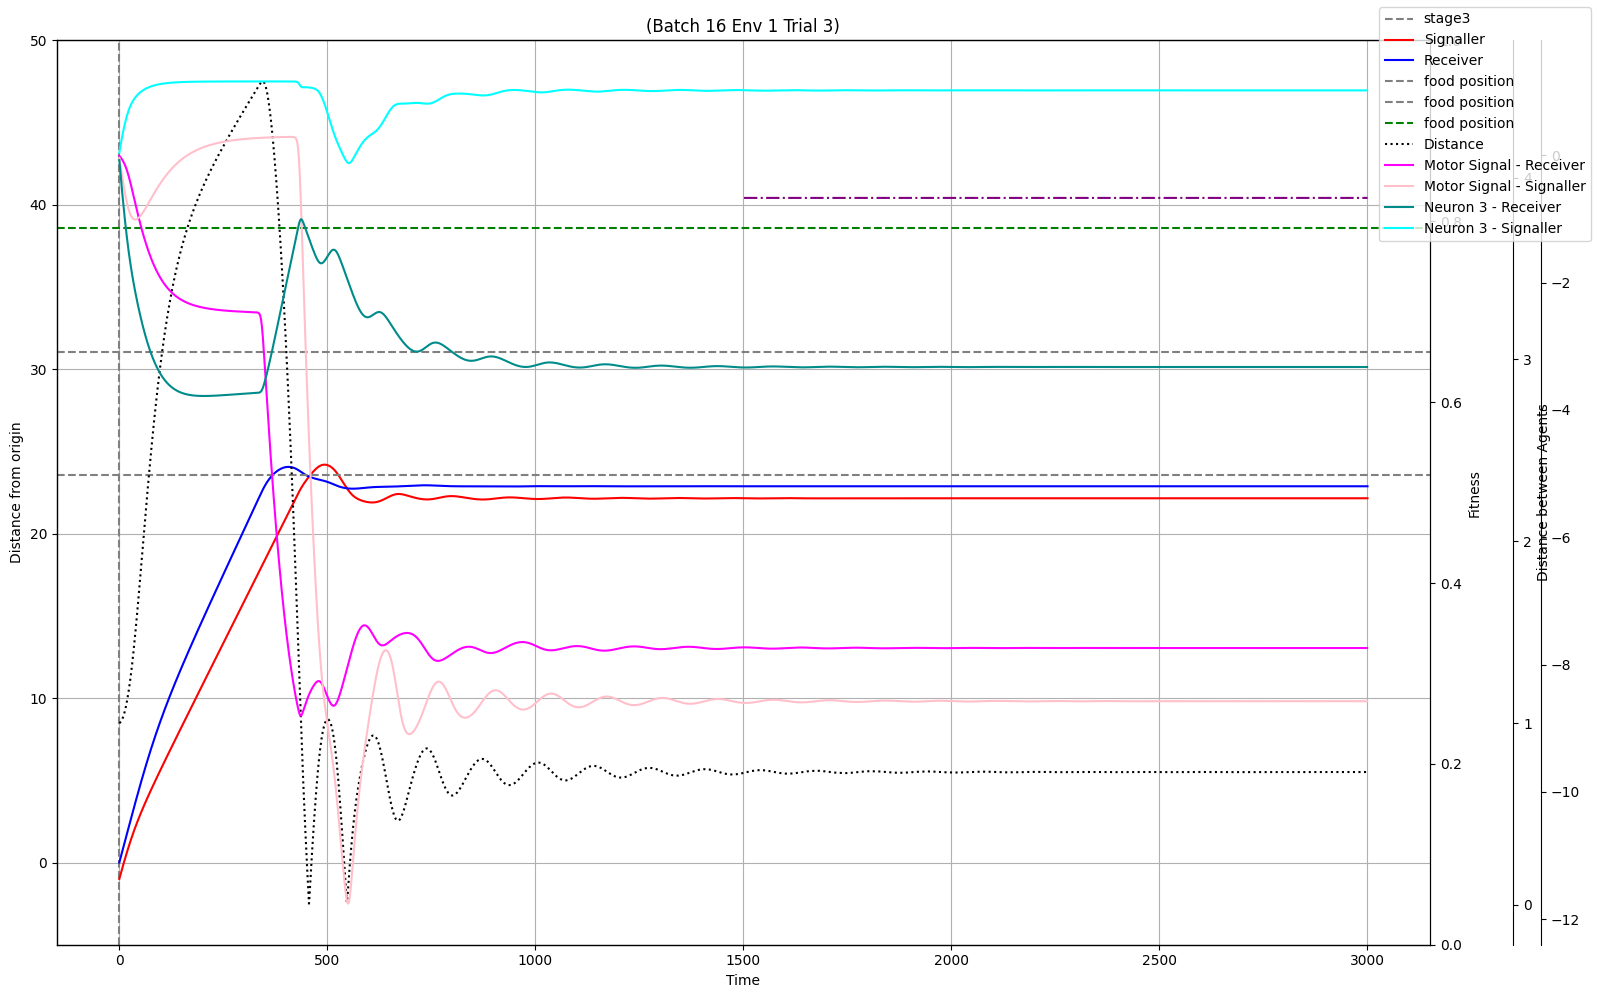

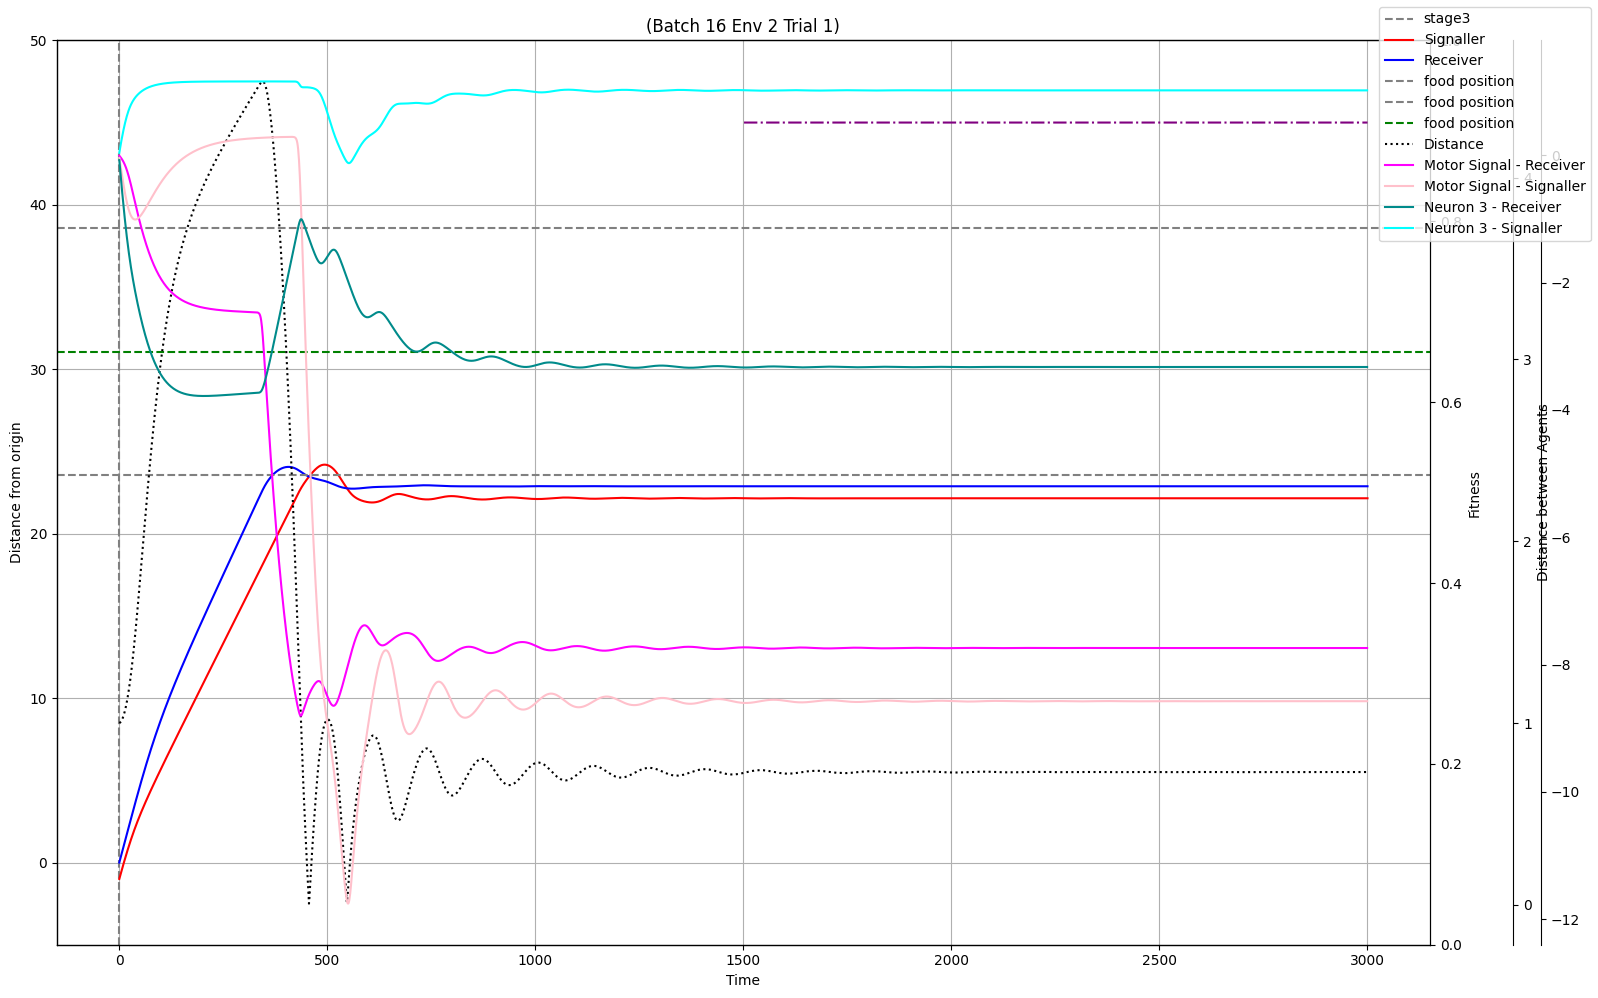

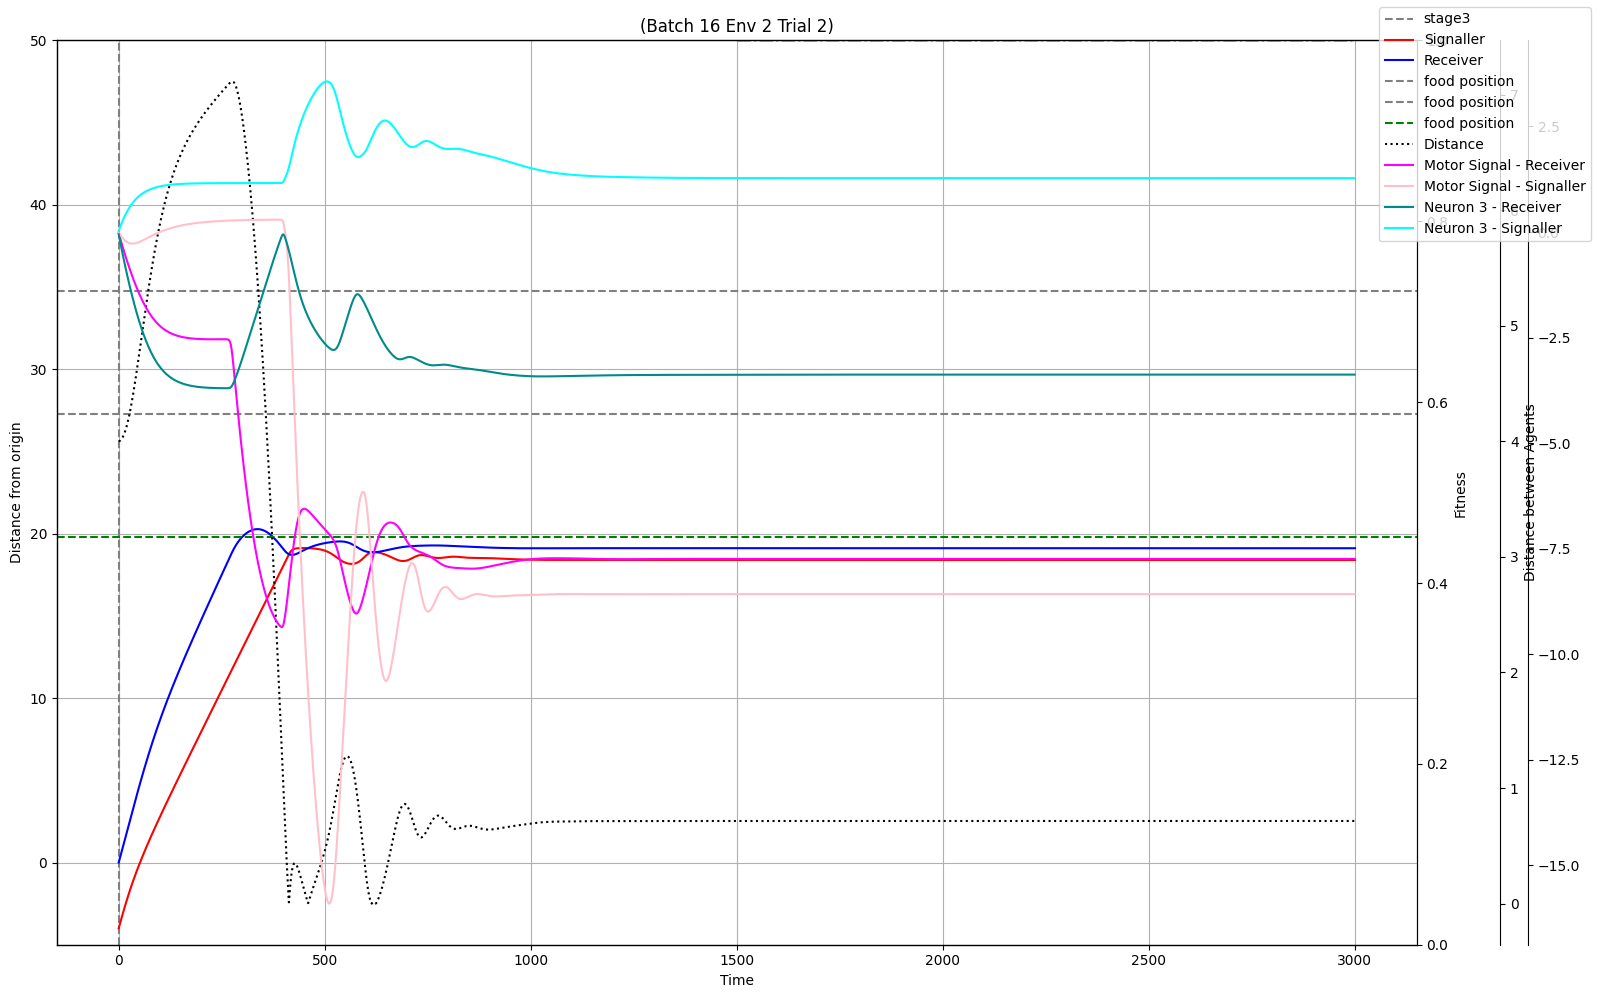

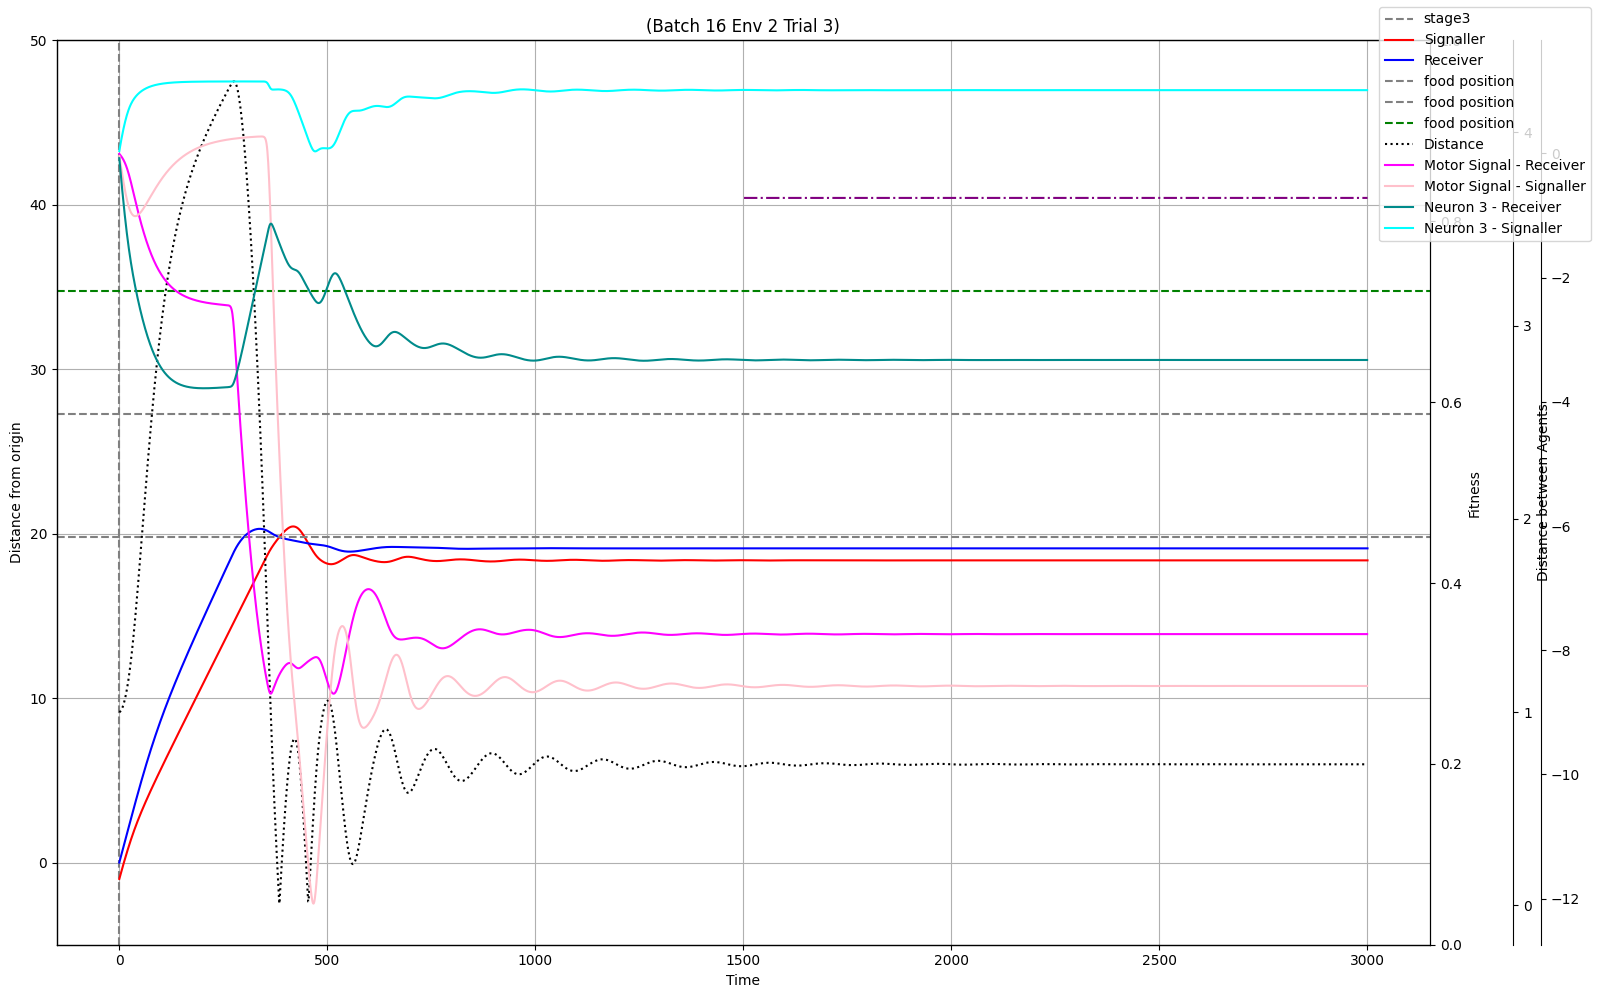

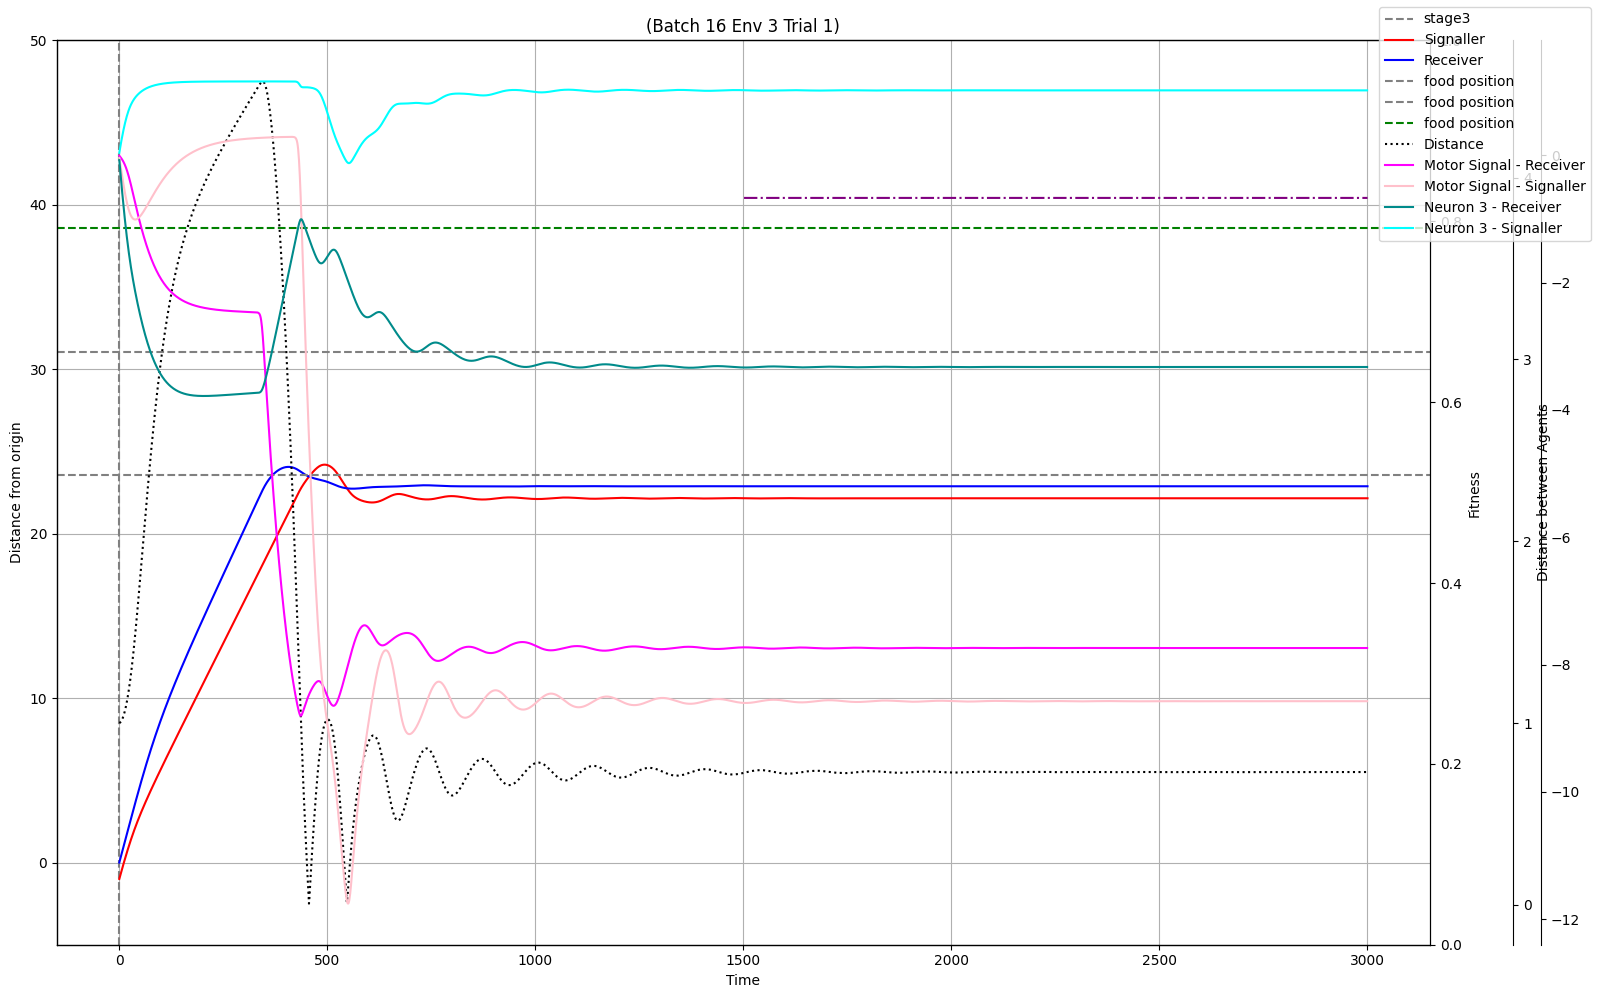

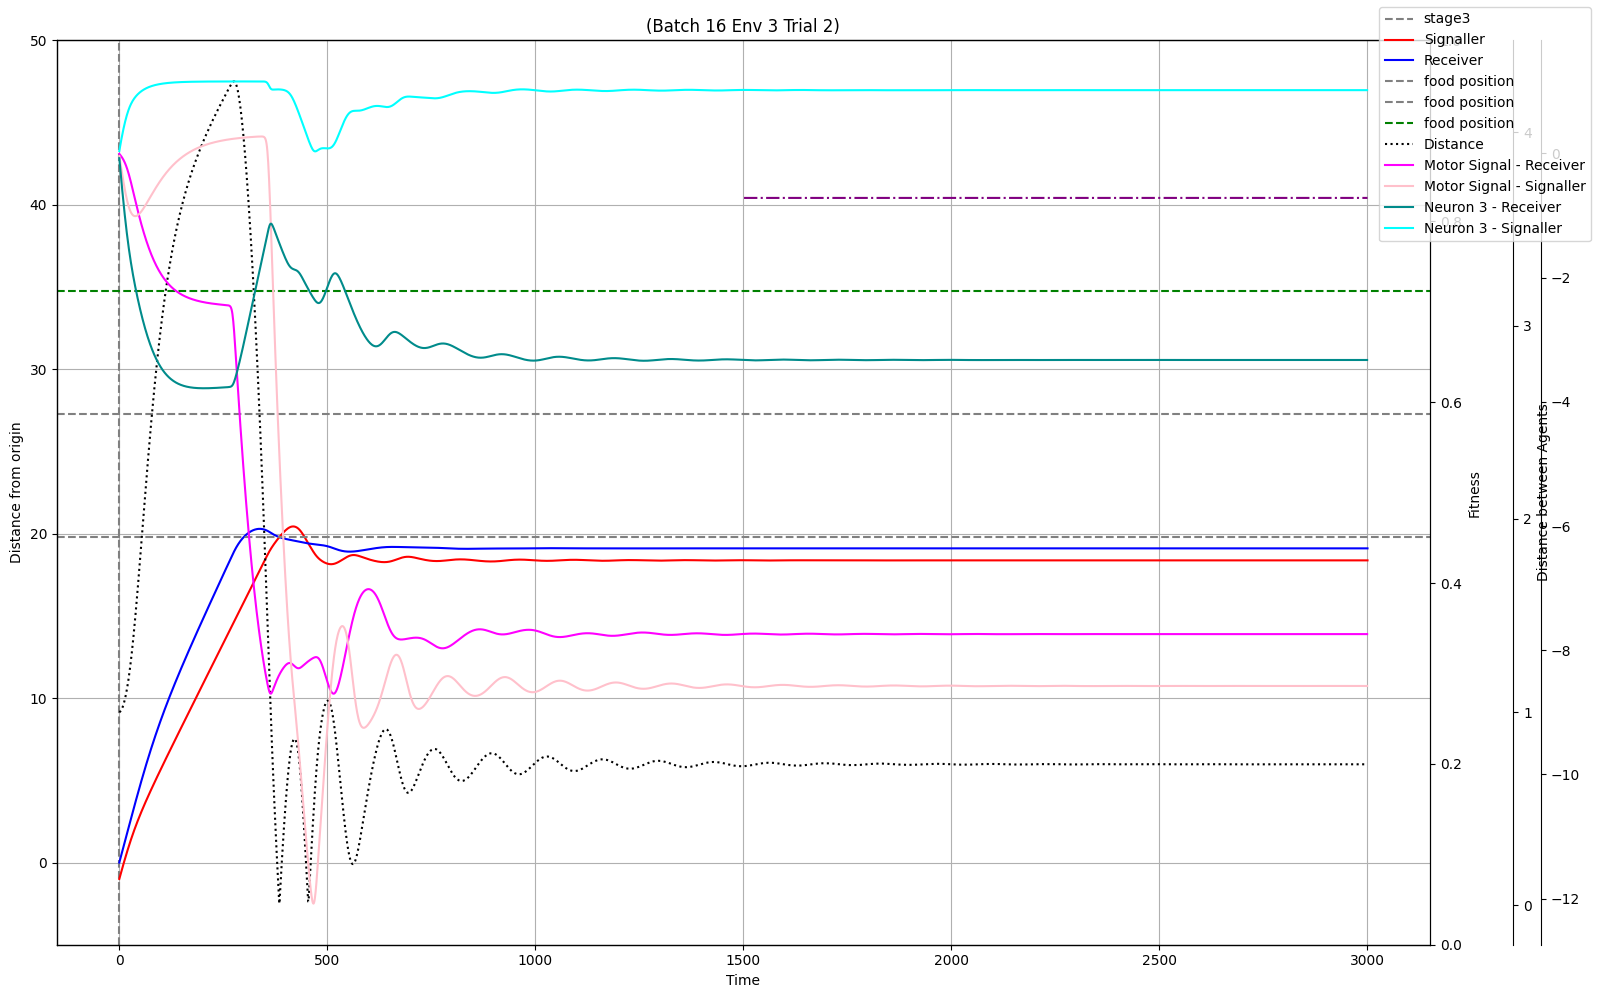

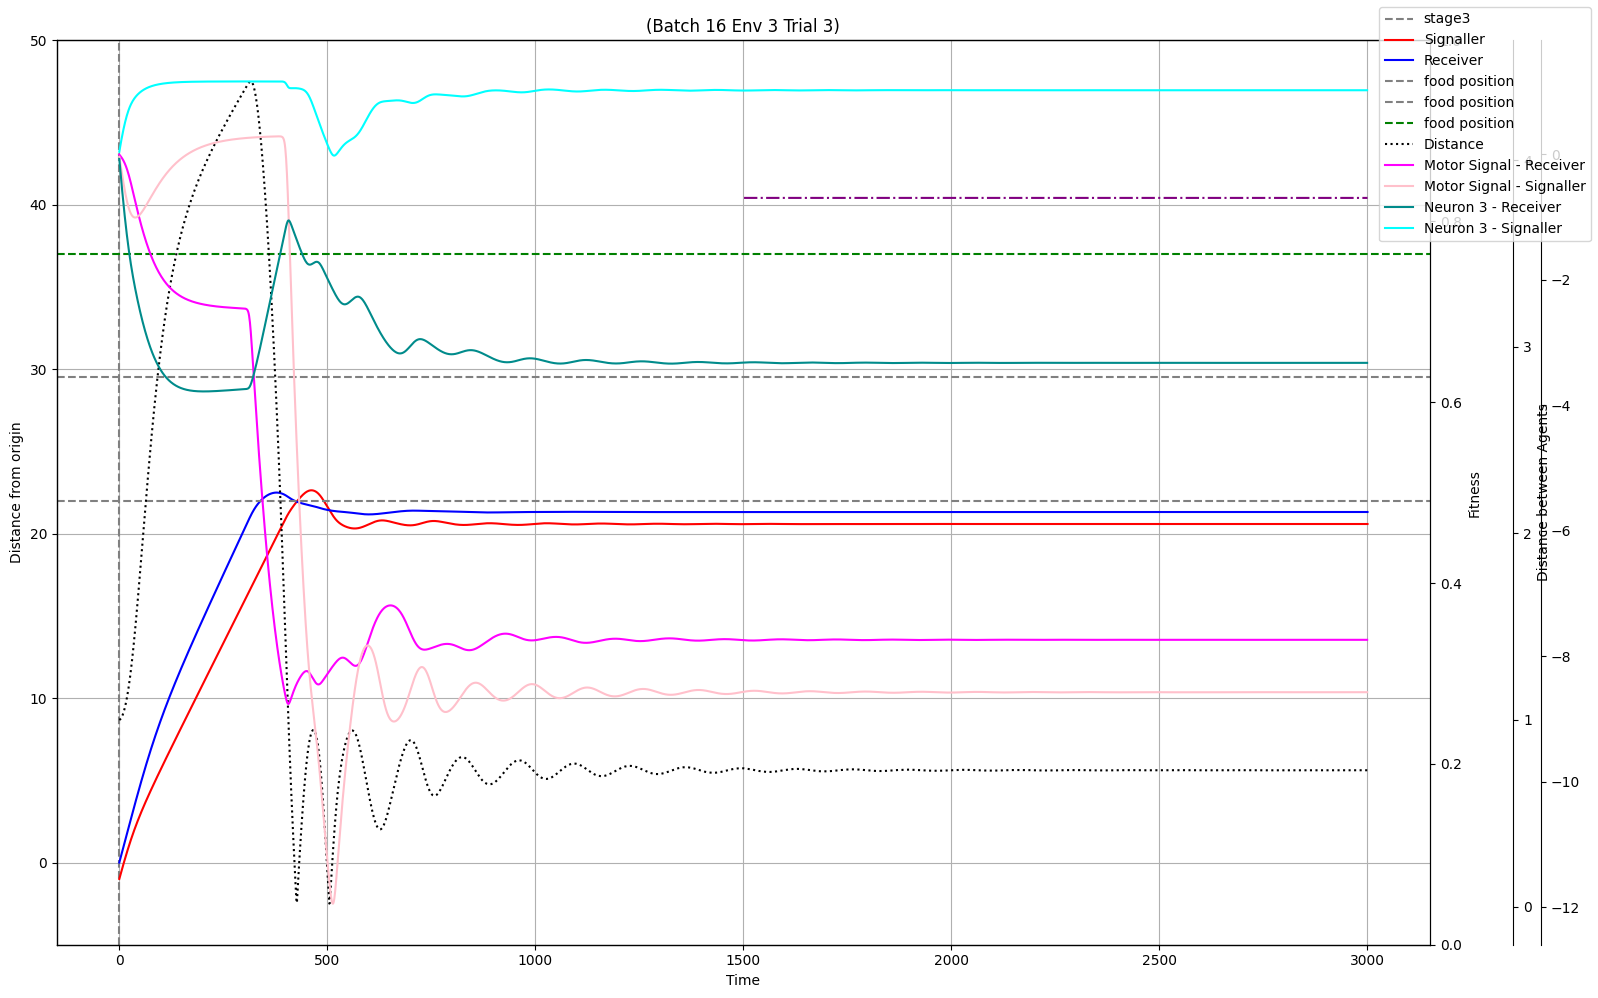

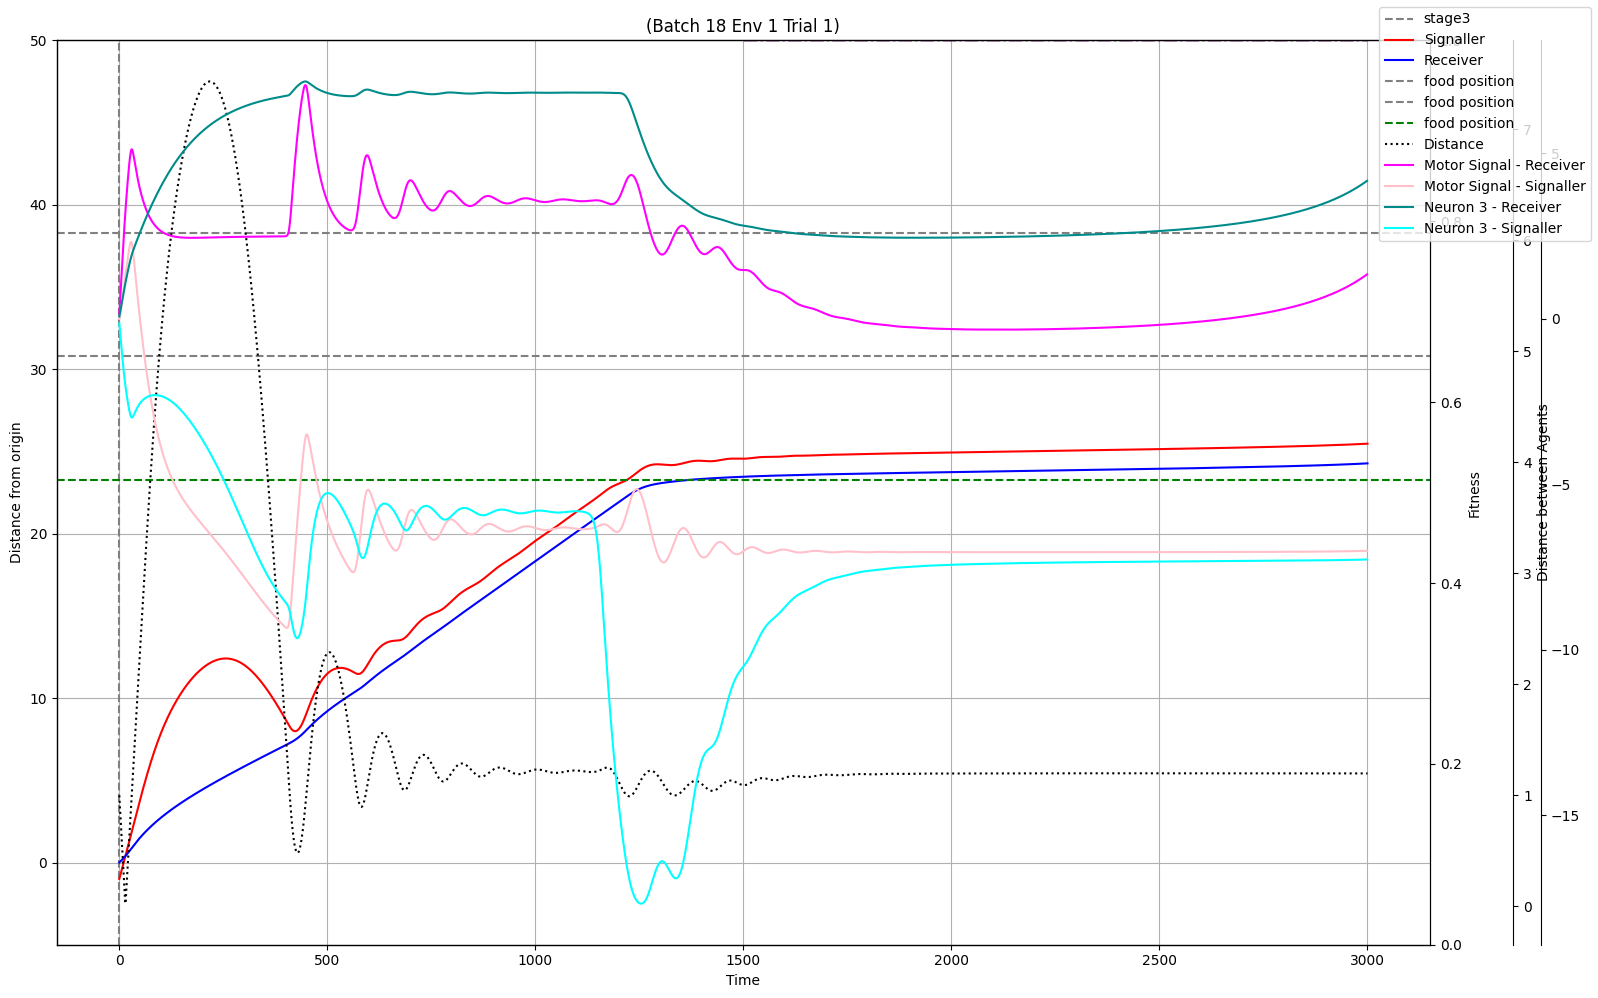

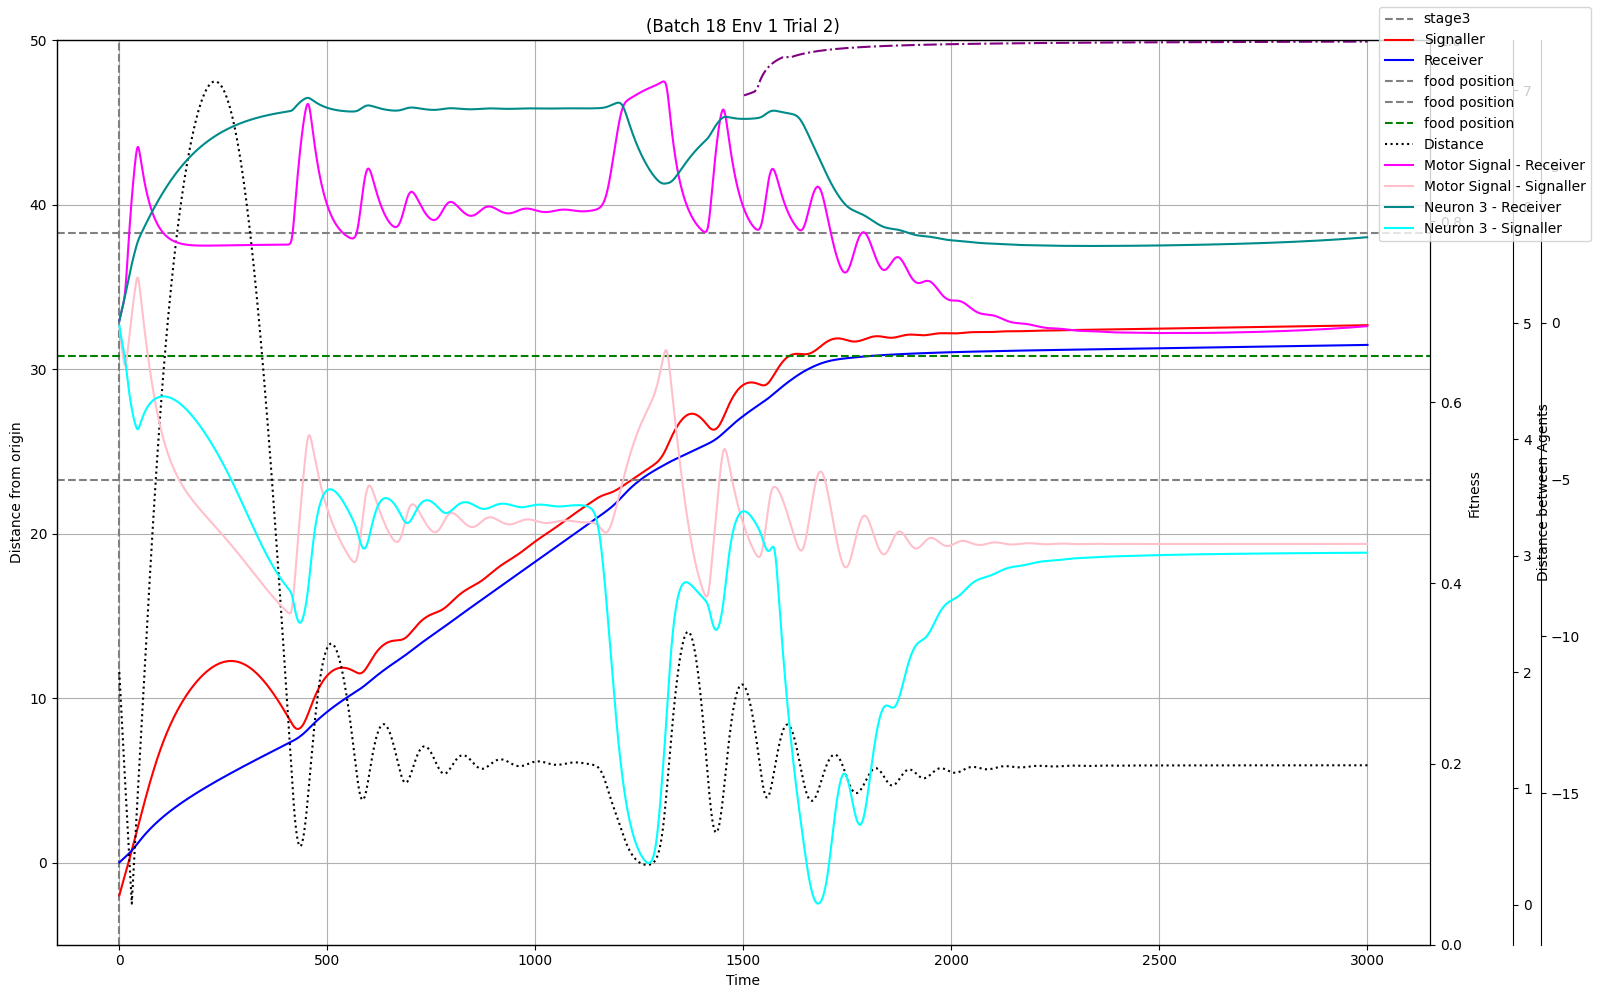

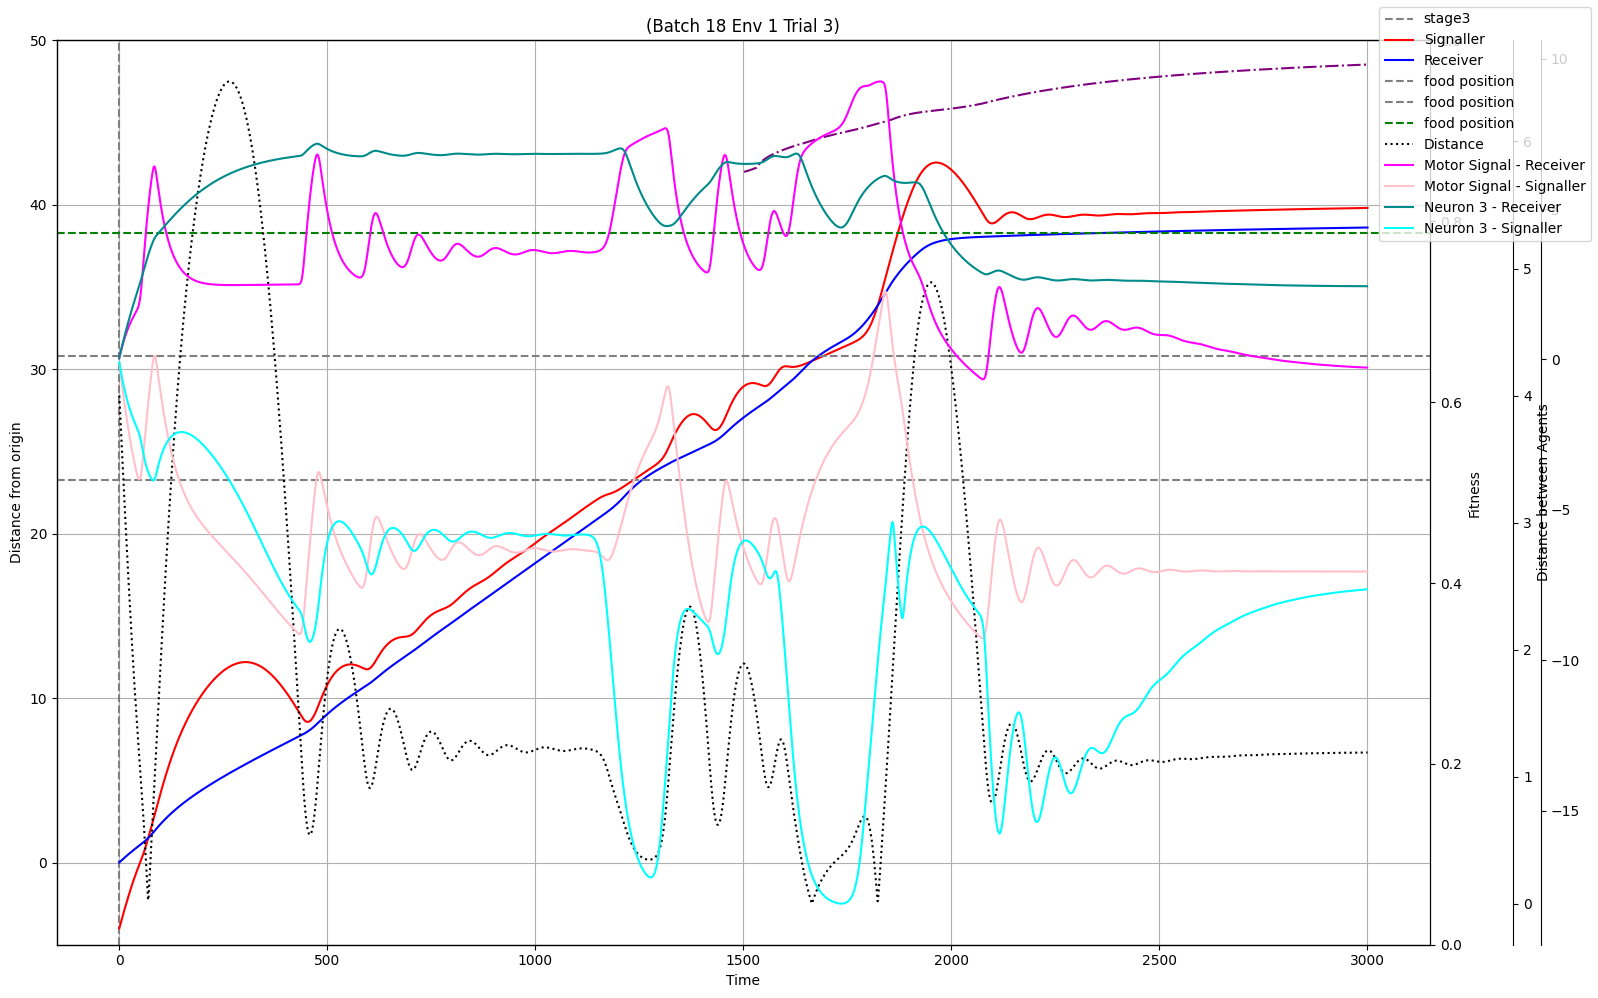

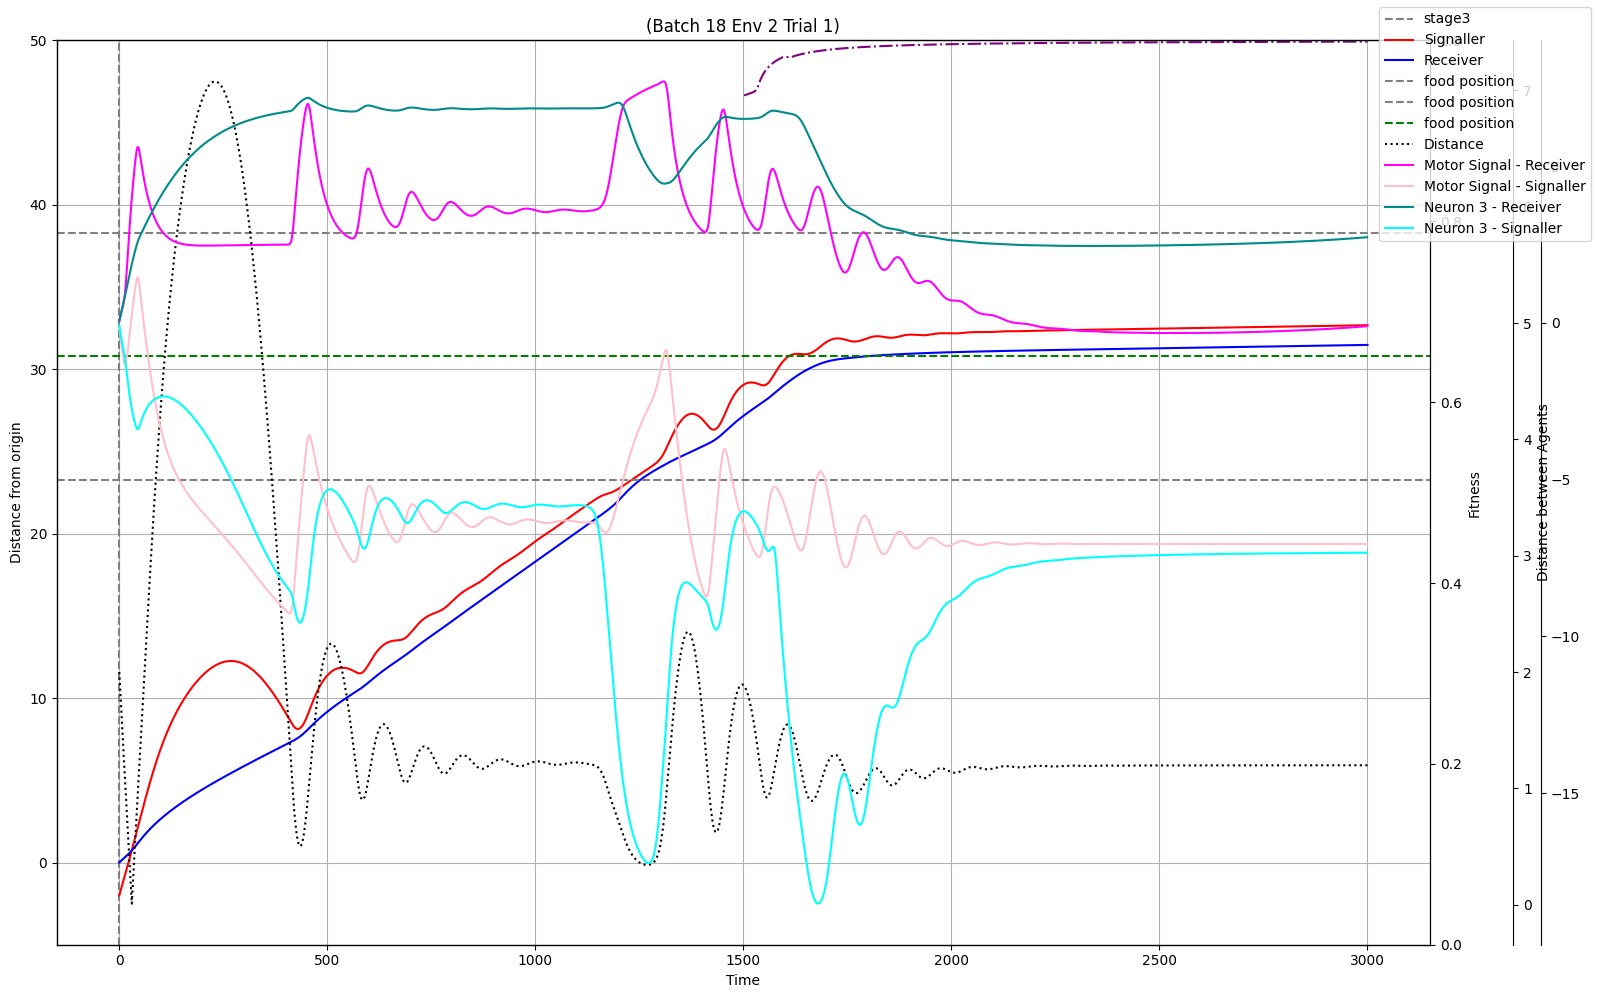

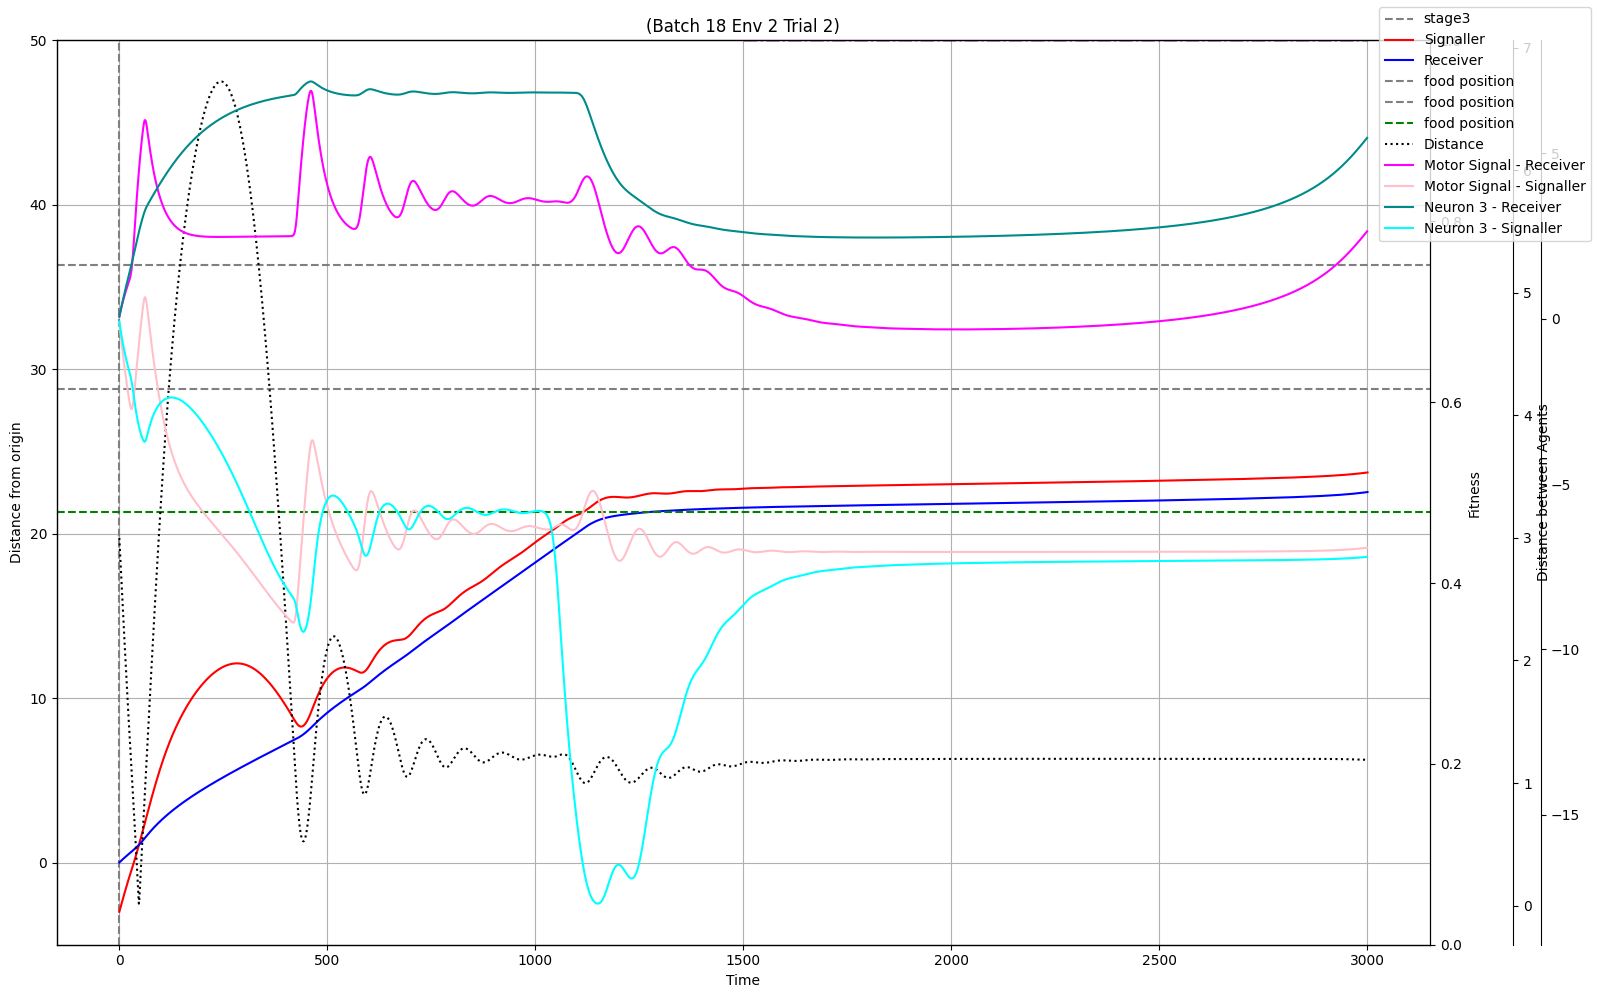

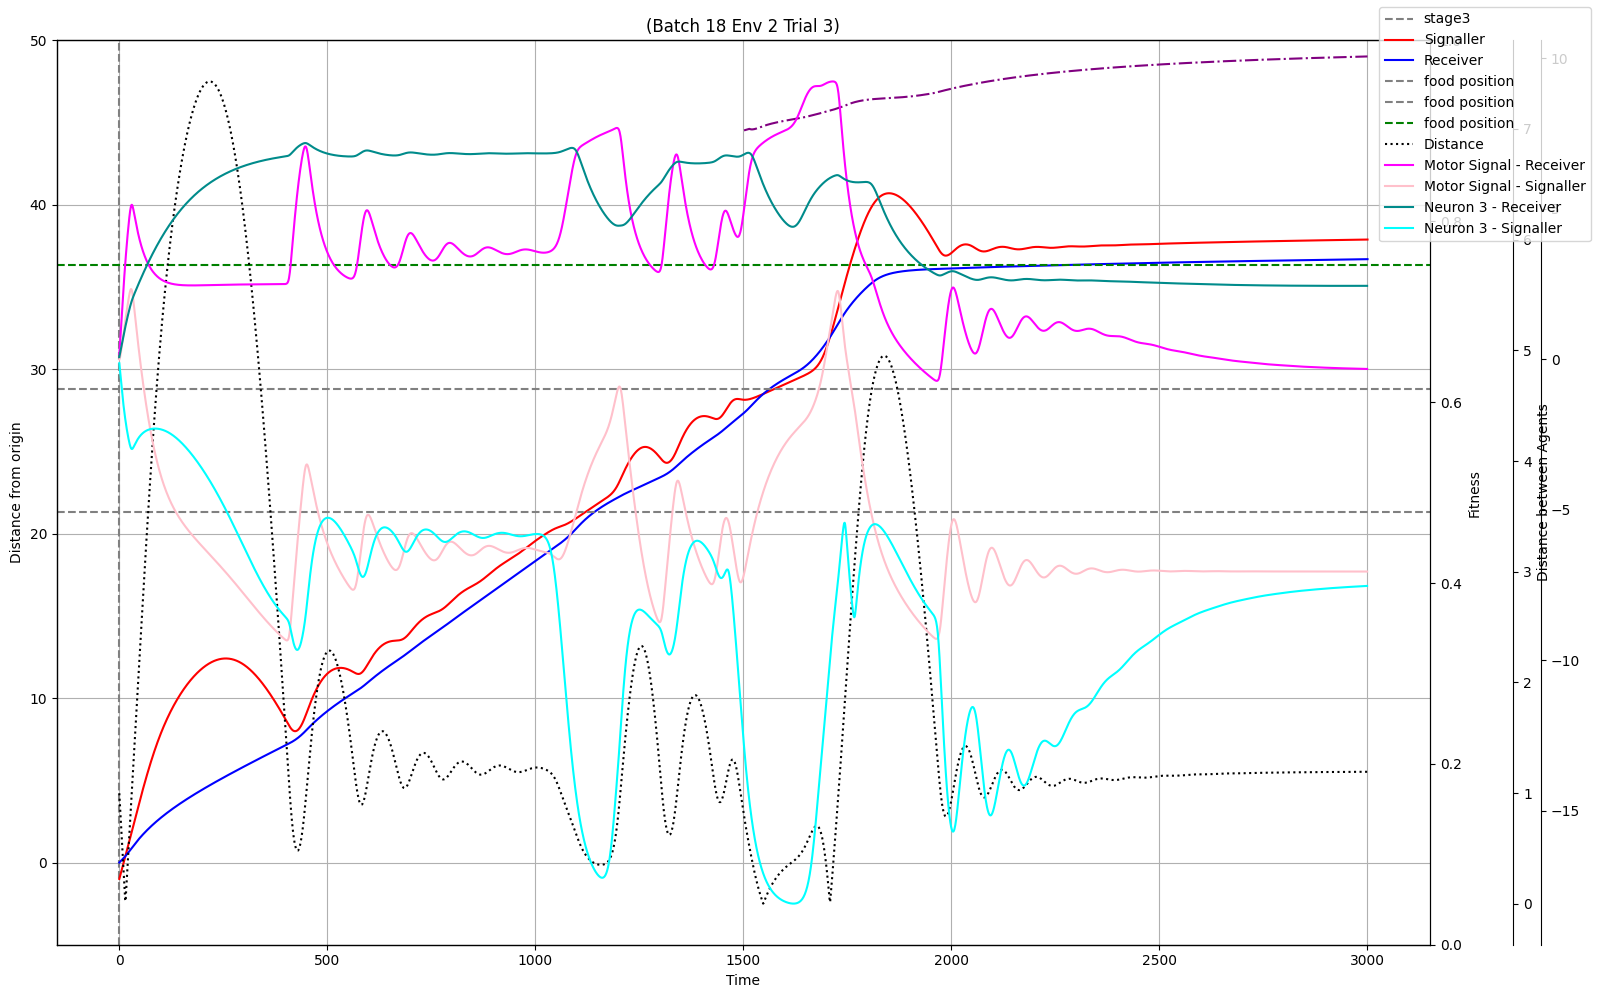

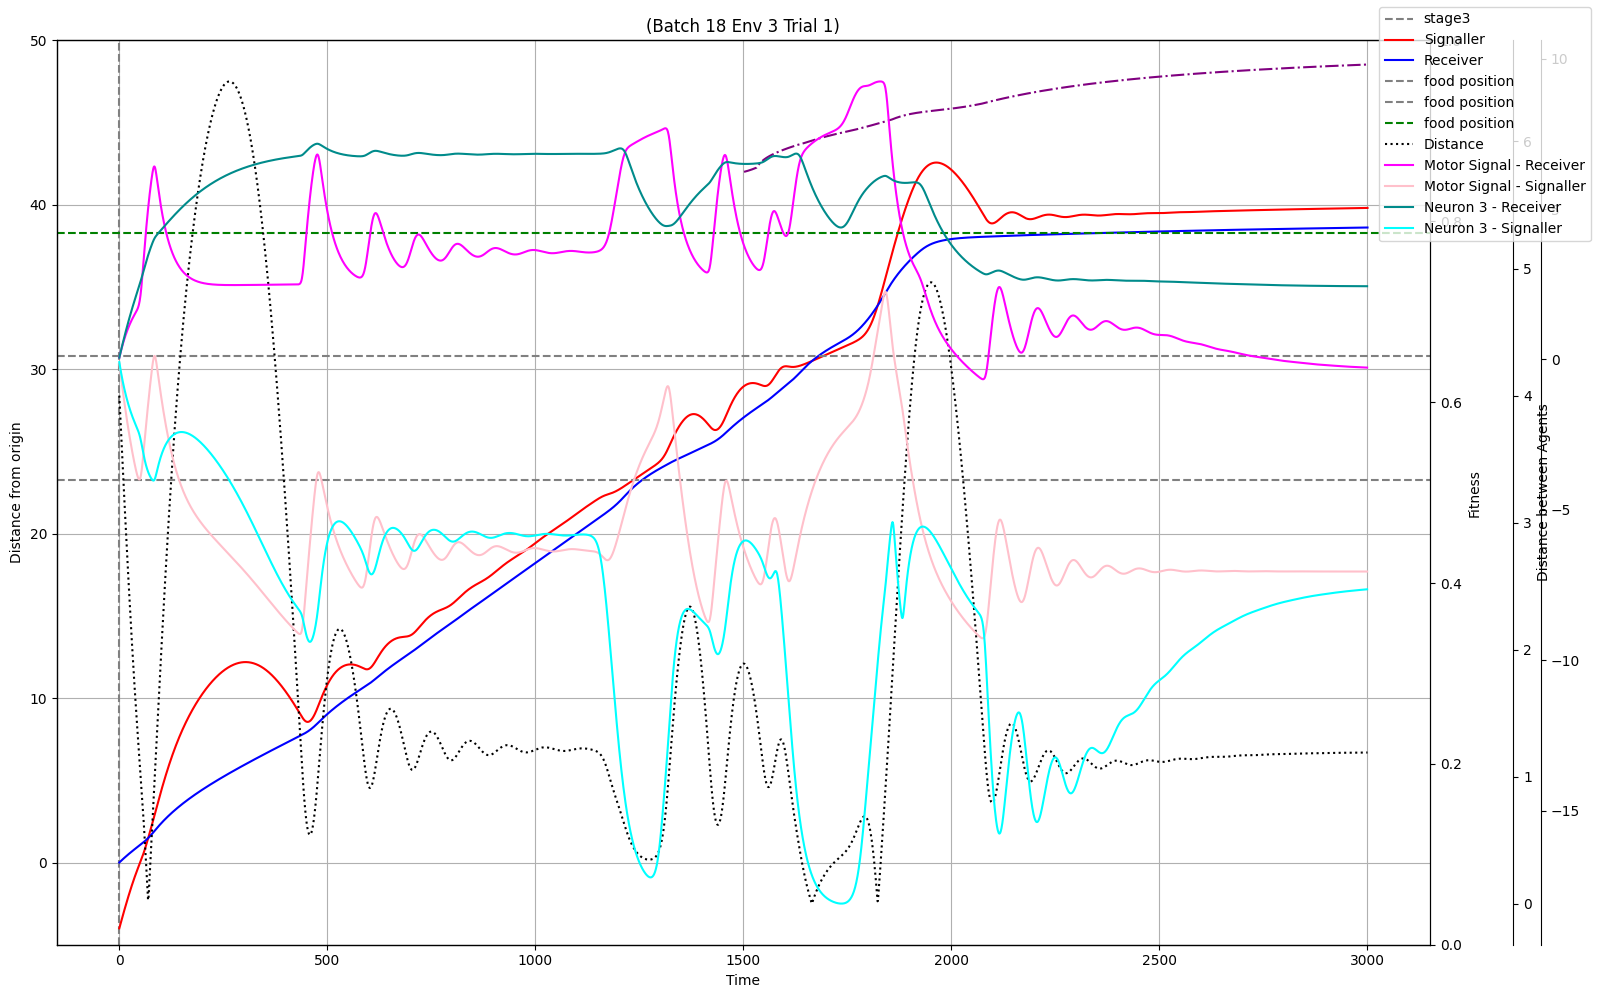

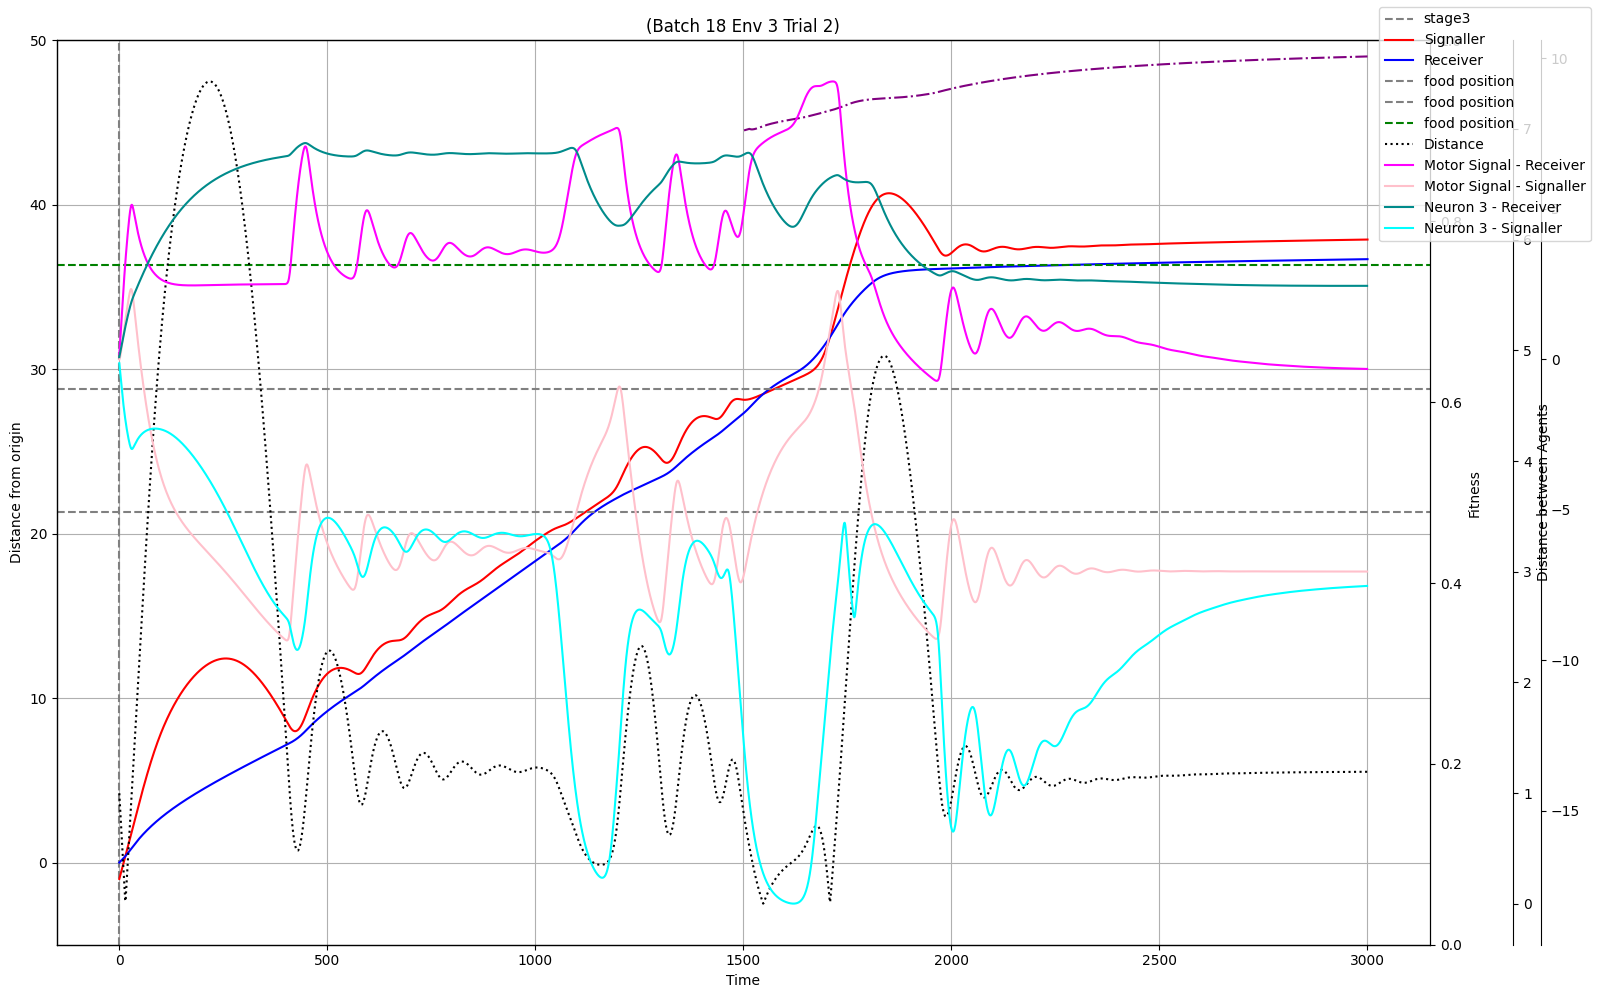

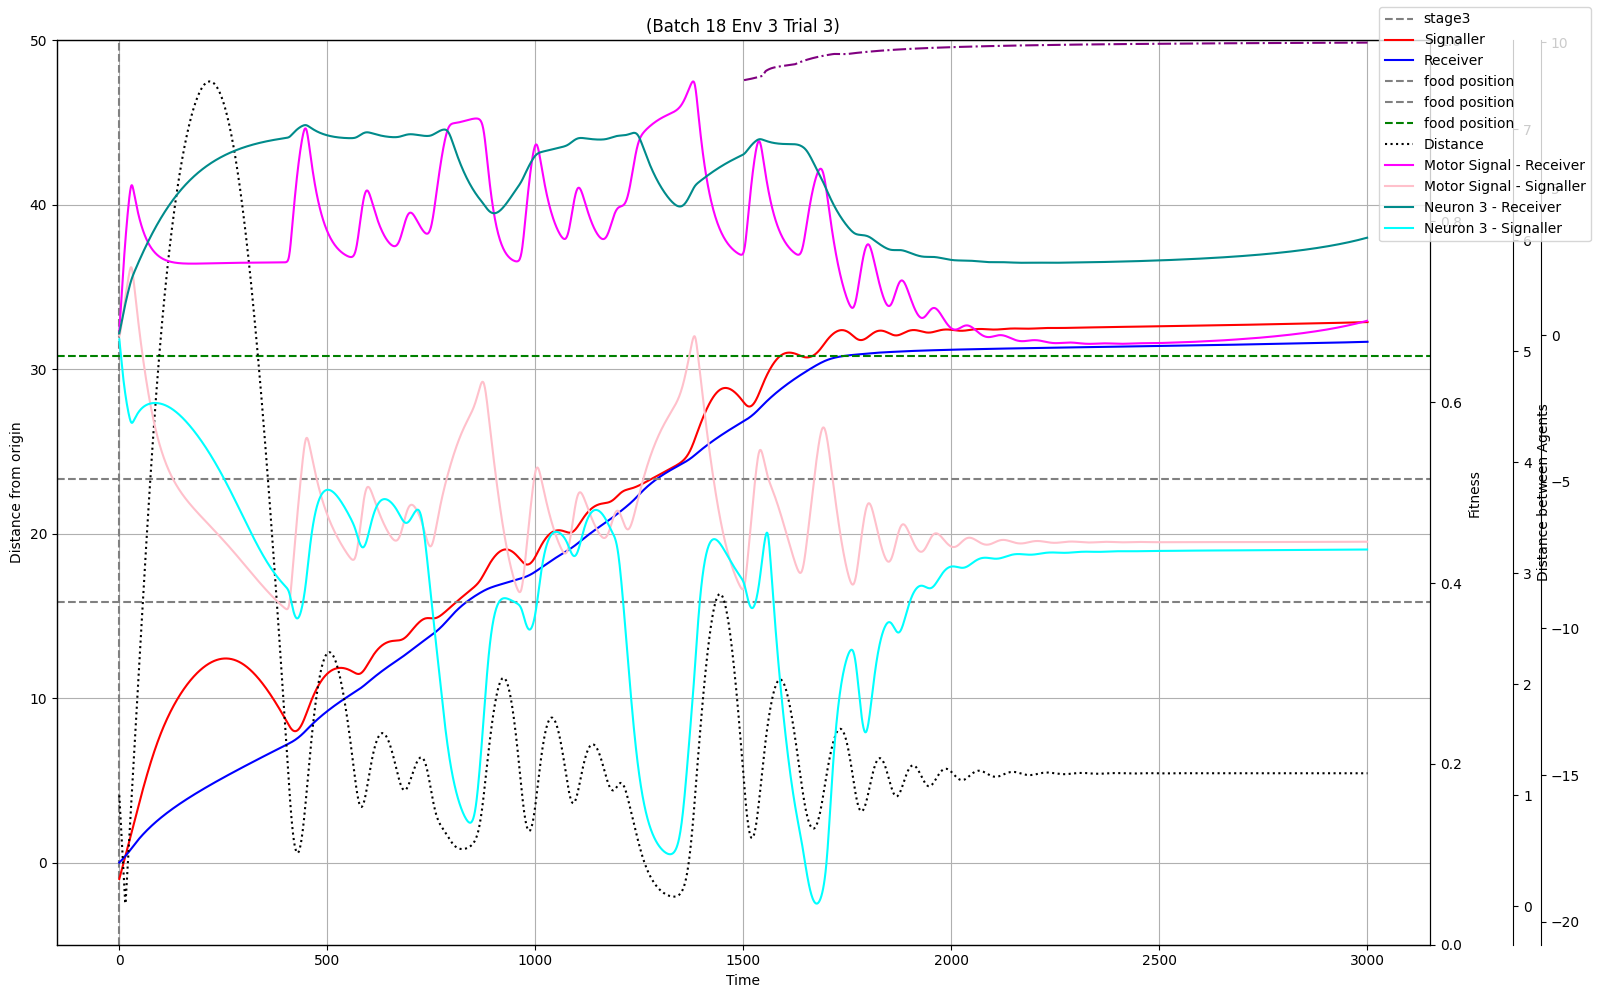

In [10]:
for batch_index, batch in enumerate(batches):
    # fig, axes = plt.subplots(3, 3, figsize=(15,12), sharey=True)
    for env_index, env in enumerate(envs):        
        for trial_index, trial in enumerate(trials):
            fig, ax = plt.subplots(figsize=(16,10))
            # ax = axes[env_index, trial_index]
            ax2 = ax.twinx()
            ax3 = ax.twinx()
            ax4 = ax.twinx()

            # Move third axis further right
            ax3.spines["right"].set_position(("outward", 60))
            ax4.spines["right"].set_position(("outward", 80))

            # Prevent frame overlap
            ax3.set_frame_on(True)
            ax3.patch.set_visible(False)

            ax4.set_frame_on(True)
            ax4.patch.set_visible(False)
  
            combined_signaller = []
            combined_receiver = []

            fitness_combined = []

            
            offset = 0

            for stage in stages:
                overall_evolution_dir_signaller = result_dir + f"batch_{batch}/run_{run}/behavior_Signaller_{stage}_{run}.dat"
                overall_evolution_dir_receiver = result_dir + f"batch_{batch}/run_{run}/behavior_Reciever_{stage}_{run}.dat"
                fitness_file = result_dir+ f"batch_{batch}/run_{run}/fitness_{stage}_{run}.dat"
                
                signaler = read_ith_line(trial*env, overall_evolution_dir_signaller)
                receiver = read_ith_line(trial*env, overall_evolution_dir_receiver)
                fitness = read_ith_line(trial*env, fitness_file)

                ax.axvline(offset, linestyle="--", label=f"{stage}", color="grey")

                stage_length = len(signaler)
                fitness_length = len(fitness)

                fitness_start = offset + (stage_length - fitness_length)
                fitness_end = offset + stage_length
                fitness_x = range(fitness_start, fitness_end)

                ax2.plot(fitness_x, fitness, linestyle="dashdot", color="purple")
                

                # combined_signaller.extend(signaller)
                combined_signaller.extend(signaler)
                combined_receiver.extend(receiver)

                offset += stage_length

            x_sig = list(range(0, len(combined_signaller)))
            x_rec = list(range(0, len(combined_receiver)))

            # distance between the signaler  and receiver
            distance = np.abs(np.array(combined_receiver) - np.array(combined_signaller))

            x_dist = list(range(0, len(distance)))
            ax3.plot(x_dist, distance, label="Distance", linestyle=":", color="black")
            # plot the signaller and receiver
            ax.plot(x_sig, combined_signaller, label=f"Signaller", color="red")
            ax.plot(x_rec, combined_receiver, label=f"Receiver", color="blue")

            landmark_file = result_dir+ f"batch_{batch}/run_{run}/landmark_location_stage3_{run}.dat"
            landmark = read_ith_line(trial*env, landmark_file)

            # plot the line marking the landmark position

            food = landmark[3]

            landmarks = [0,1,2]
            for i in landmarks:
                if (landmark[i] != food):
                    ax.axhline(y=landmark[i], linestyle="--", label="food position", color="grey")


            ax.axhline(y=food, linestyle="--", label="food position", color="green")

        


            # get the neural states
            signaller_neural_state_1_file = result_dir+ f"batch_{batch}/run_{run}/signaller_neuron1_{stage}_0.dat"
            signaller_neural_state_2_file = result_dir+ f"batch_{batch}/run_{run}/signaller_neuron2_{stage}_0.dat"
            signaller_neural_state_3_file = result_dir+ f"batch_{batch}/run_{run}/signaller_neuron3_{stage}_0.dat"

            receiver_neural_state_1_file = result_dir+ f"batch_{batch}/run_{run}/receiver_neuron1_{stage}_0.dat"
            receiver_neural_state_2_file = result_dir+ f"batch_{batch}/run_{run}/receiver_neuron2_{stage}_0.dat"
            receiver_neural_state_3_file = result_dir+ f"batch_{batch}/run_{run}/receiver_neuron3_{stage}_0.dat"
            
            signaler_neuron1 = read_ith_line(trial*env, signaller_neural_state_1_file)
            signaler_neuron2 = read_ith_line(trial*env, signaller_neural_state_2_file)
            signaler_neuron3 = read_ith_line(trial*env, signaller_neural_state_3_file)

            receiver_neuron1 = read_ith_line(trial*env, receiver_neural_state_1_file)
            receiver_neuron2 = read_ith_line(trial*env, receiver_neural_state_2_file)
            receiver_neuron3 = read_ith_line(trial*env, receiver_neural_state_3_file)
            
            # plot the motor 
            signaler_motor = []
            receiver_motor = []

            for p in range(len(signaler_neuron1)):
                signaler_motor.append(signaler_neuron2[p]-signaler_neuron1[p])

            for p in range(len(receiver_neuron1)):
                receiver_motor.append(receiver_neuron2[p]-receiver_neuron1[p])

            x_receiver_motor = list(range(0, len(receiver_motor)))
            x_signaller_motor = list(range(0, len(signaler_motor)))

            ax4.plot(x_receiver_motor, receiver_motor, label=f"Motor Signal - Receiver", color="fuchsia")
            ax4.plot(x_signaller_motor, signaler_motor, label=f"Motor Signal - Signaller", color="pink")

            # plot the other neuron
            
            ax4.plot(list(range(0, len(receiver_neuron3))), receiver_neuron3, label=f"Neuron 3 - Receiver", color="darkcyan")
            ax4.plot(list(range(0, len(signaler_neuron3))), signaler_neuron3, label=f"Neuron 3 - Signaller", color="cyan")

            
            ax.set_xlabel("Time")
            ax.set_ylabel("Distance from origin")
            ax.set_ylim(bottom=-5, top=50)
            ax2.set_ylim(bottom=0, top=1)
            ax2.set_ylabel("Fitness")

            # ax3.set_ylabel("Neuron Values")
            ax3.set_ylabel("Distance between Agents")

            ax.set_title(f"(Batch {batch} Env {env} Trial {trial})")
            ax.grid(True)
            

            fig.legend()
            fig.tight_layout()
            fig.show()